In [ ]:
!pip install arch xgboost scikit-learn matplotlib seaborn pandas numpy scipy tensorflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 26.1 MB/s eta 0:00:00


In [ ]:
import os
import warnings
warnings.filterwarnings('ignore') # silence non-critical library warnings
RAW_DATA_PATH = 'btc_1h_data_2018_to_2025.csv'
DIR_CLEAN = 'outputs/clean'
DIR_FEATURES = 'outputs/features'
DIR_MODELS = 'outputs/models'
DIR_PREDS = 'outputs/predictions'
DIR_FIGURES = 'outputs/figures'
DIR_METRICS = 'outputs/metrics'
DIR_NOTES = 'outputs/notes'

for d in [DIR_CLEAN, DIR_FEATURES, DIR_MODELS, DIR_PREDS, DIR_FIGURES, DIR_METRICS, DIR_NOTES]:
    os.makedirs(d, exist_ok=True)
# exist_ok avoids an error if the folder already exists

FREQ = '1h'
BARS_PER_DAY = 24
BARS_PER_WEEK = 168
BARS_PER_MONTH = 720
# Bars per forecast horizon (hourly data)

HORIZONS = {'1d': 1, '1w': 7, '1m': 30}

TRAIN_START = '2018-01-01'
VAL_START = '2023-01-01'
TEST_START = '2024-01-01'
TEST_END = '2026-2-1'
# Chronological train / validation / test boundaries

WF_STEP_DAYS = 30
WF_MAX_WINDOW_DAYS = 365
# Walk-forward validation windows to limit overfitting

GARCH_REFIT_DAYS = 30
# Refit GARCH every 30 days during the test period

LAG_DEPTHS = [1, 2, 3, 6, 12, 24, 48, 168]
ROLLING_WINDOWS = [24, 48, 168, 336, 720]


XGB_PARAMS = {
    'n_estimators': 100,
    'max_depth': 5,
    'learning_rate': 0.08,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 30}
# XGBoost hyperparameters

RUN_LSTM = True
LSTM_SEQ_LEN = 72
LSTM_EPOCHS = 50
LSTM_BATCH = 128
LSTM_LR = 0.0005
# LSTM hyperparameters

RANDOM_SEED = 42
import numpy as np
np.random.seed(RANDOM_SEED)
# Fixed random seed for reproducibility

print(f'Training: {TRAIN_START} -> {VAL_START}')
print(f'Validation: {VAL_START} -> {TEST_START}')
print(f'Test: {TEST_START} -> {TEST_END}')
# Confirm the configuration

Training: 2018-01-01 -> 2023-01-01
Validation: 2023-01-01 -> 2024-01-01
Test: 2024-01-01 -> 2026-2-1


In [ ]:
import pandas as pd
raw = pd.read_csv(RAW_DATA_PATH)
print(f'Raw Shape: {raw.shape}')
print(f'Columns: {raw.columns.tolist()}')
# Confirm the columns loaded

Raw Shape: (71086, 12)
Columns: ['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time', 'Quote asset volume', 'Number of trades', 'Taker buy base asset volume', 'Taker buy quote asset volume', 'Ignore']


In [ ]:
KEEP_COLS = [
    'Open time', 'Open', 'High', 'Low', 'Close',
    'Volume', 'Quote asset volume', 'Number of trades',
    'Taker buy base asset volume', 'Taker buy quote asset volume']
df = raw[KEEP_COLS].copy()
df.columns = [
    'timestamp', 'open', 'high', 'low', 'close',
    'volume', 'quote_asset_volume', 'num_trades',
    'taker_buy_base_volume', 'taker_buy_quote_volume']
# Rename columns to snake_case

# Correctly generate timestamps assuming hourly data starting from TRAIN_START
start_date = pd.to_datetime(TRAIN_START)
# Generate a date range with '1h' frequency for the length of the raw data
df['timestamp'] = pd.date_range(start=start_date, periods=len(df), freq='1h')

df = df.dropna(subset=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
# Drop rows without a valid timestamp

assert df['timestamp'].is_monotonic_increasing, 'Error'
print(f'Clean Shape: {df.shape}')
# Verify the time index is monotonic

n_dupes = df['timestamp'].duplicated().sum()
print(f'Duplicate timestamps: {n_dupes}')
df = df.drop_duplicates(subset=['timestamp'])
# Drop duplicate timestamps

bad_highlow = (df['high'] < df['low']).sum()
bad_vol = (df['volume'] < 0).sum()
bad_trades = (df['num_trades'] < 0).sum()
print(f'High < Low violations: {bad_highlow}')
print(f'Negative volume rows: {bad_vol}')
print(f'Negative trade rows: {bad_trades}')
# Flag impossible values for manual review

time_diffs = df['timestamp'].diff().dropna()
expected = pd.Timedelta('1h')
gaps = time_diffs[time_diffs > expected * 1.5]
print(f'Time gaps detected: {len(gaps)}')
if len(gaps) > 0:
    print('Largest gaps:')
    print(gaps.nlargest(5))
# Detect gaps larger than 1.5 hours

print('Missing values per column:')
print(df.isnull().sum())
# Missing values per column

df = df.set_index('timestamp')
# Use the timestamp as the row index

clean_path = f'{DIR_CLEAN}/btc_1h_clean.csv'
df.to_csv(clean_path)
print(f'\n Clean dataset saved to {clean_path}')
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} -> {df.index.max()}')
# Save the cleaned dataset

Clean Shape: (71086, 10)
Duplicate timestamps: 0
High < Low violations: 0
Negative volume rows: 0
Negative trade rows: 0
Time gaps detected: 0
Missing values per column:
timestamp                 0
open                      0
high                      0
low                       0
close                     0
volume                    0
quote_asset_volume        0
num_trades                0
taker_buy_base_volume     0
taker_buy_quote_volume    0
dtype: int64

 Clean dataset saved to outputs/clean/btc_1h_clean.csv
Shape: (71086, 9)
Date range: 2018-01-01 00:00:00 -> 2026-02-09 21:00:00


In [ ]:
data_dict = pd.DataFrame([
    ['timestamp',               'Bar open timestamp (UTC)',                    'datetime', 'raw'],
    ['open',                    'Opening price of the bar',                    'USD',      'raw'],
    ['high',                    'Highest price during the bar',                'USD',      'raw'],
    ['low',                     'Lowest price during the bar',                 'USD',      'raw'],
    ['close',                   'Closing price of the bar',                    'USD',      'raw'],
    ['volume',                  'BTC traded volume',                           'BTC',      'raw'],
    ['quote_asset_volume',      'USD equivalent of volume traded',             'USD',      'raw'],
    ['num_trades',              'Number of individual trades in the bar',      'count',    'raw'],
    ['taker_buy_base_volume',   'BTC volume from market buy (taker) orders',   'BTC',      'raw'],
    ['taker_buy_quote_volume',  'USD volume from market buy (taker) orders',   'USD',      'raw'],
    ['log_return',              'Log return from bar to bar close',            'ratio',    'engineered'],
    ['future_1d_vol',           'Realized vol over next 24 hours (target)',    'ratio',    'target'],
    ['future_1w_vol',           'Realized vol over next 168 hours (target)',   'ratio',    'target'],
    ['future_1m_vol',           'Realized vol over next 720 hours (target)',   'ratio',    'target'],
], columns=['variable', 'description', 'units', 'type'])

data_dict.to_csv(f'{DIR_NOTES}/data_dictionary.csv', index=False)
print('Data dictionary saved.')
# Data dictionary

Data dictionary saved.


In [ ]:
import numpy as np
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df = df.iloc[1:].copy()
# Hourly log returns; the first row has no prior close, so it is dropped

print(f'Return series length : {len(df)}')
print(f'Mean return : {df["log_return"].mean():.6f}')
print(f'Std return : {df["log_return"].std():.6f}')
print(f'Min / Max return : {df["log_return"].min():.4f} / {df["log_return"].max():.4f}')
# Summary statistics

Return series length : 71085
Mean return : 0.000023
Std return : 0.007288
Min / Max return : -0.2010 / 0.1603


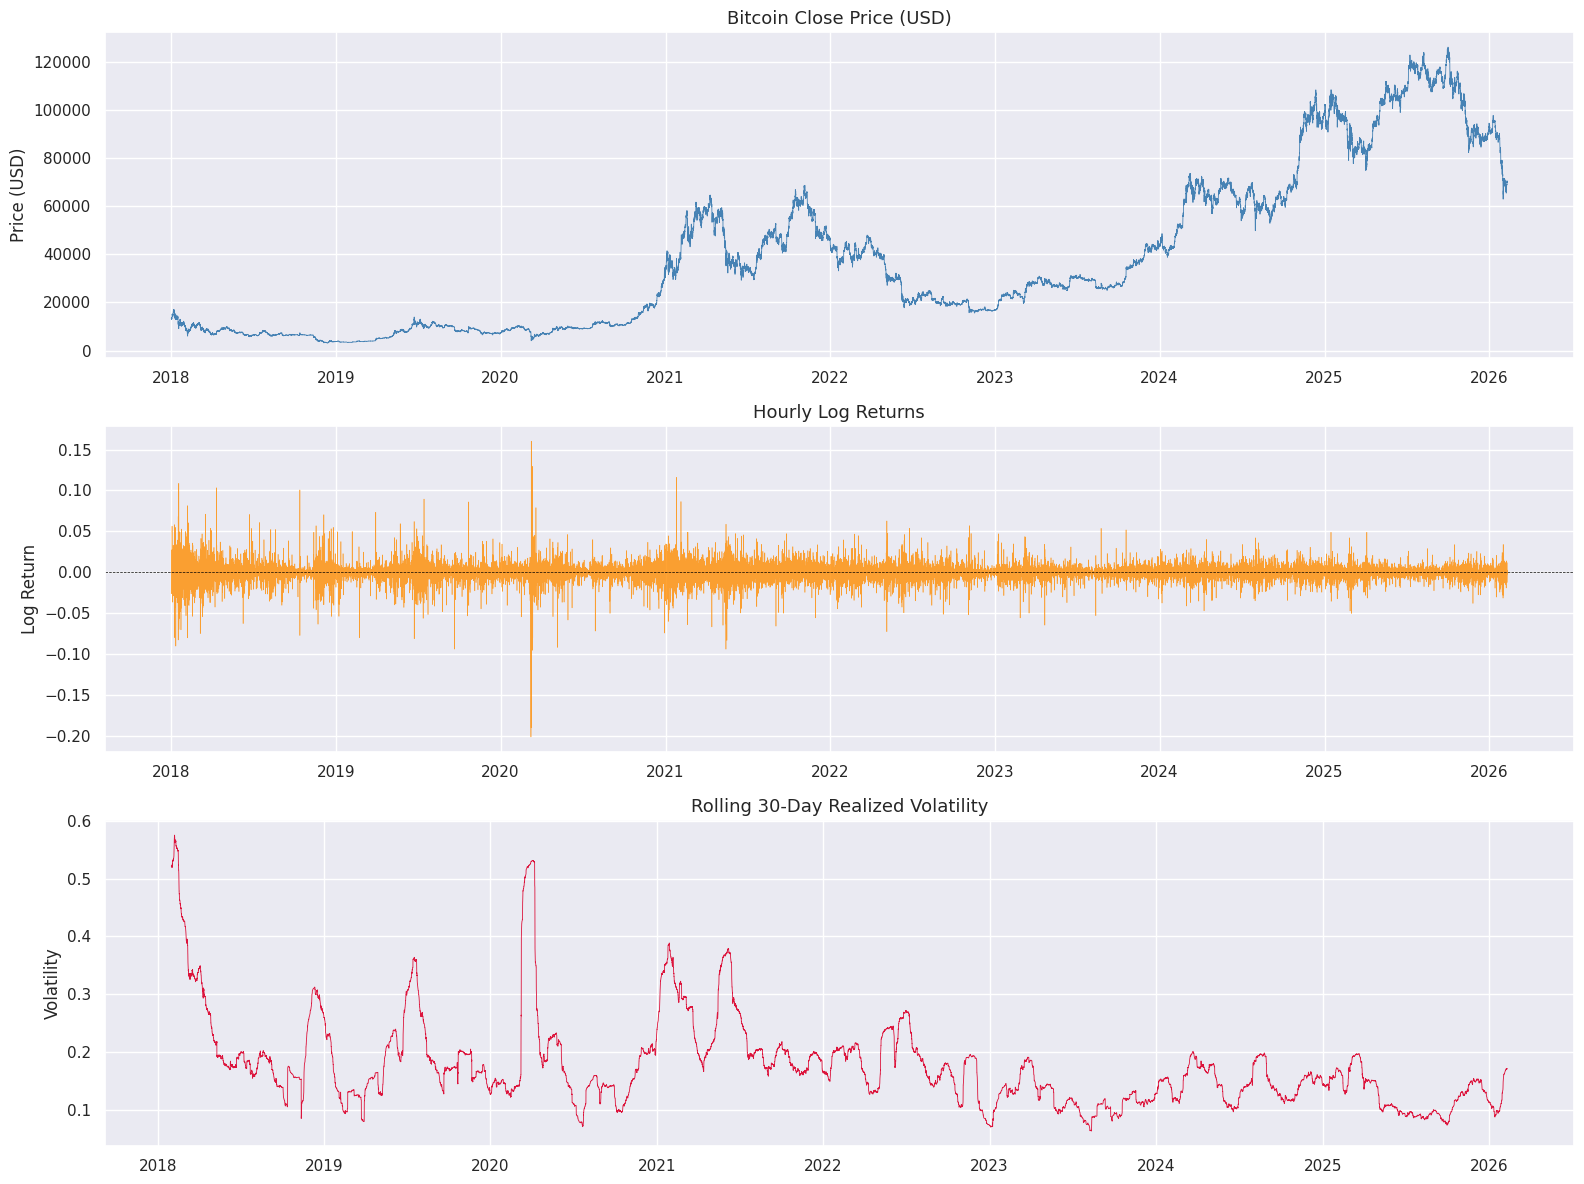

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='darkgrid')
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
# Plot styling


axes[0].plot(df.index, df['close'], color='steelblue', linewidth=0.6)
axes[0].set_title('Bitcoin Close Price (USD)', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].plot(df.index, df['log_return'], color='darkorange', linewidth=0.4, alpha=0.8)
axes[1].set_title('Hourly Log Returns', fontsize=13)
axes[1].set_ylabel('Log Return')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

roll_vol = df['log_return'].rolling(window=BARS_PER_MONTH).std() * np.sqrt(BARS_PER_MONTH)
axes[2].plot(df.index, roll_vol, color='crimson', linewidth=0.6)
axes[2].set_title('Rolling 30-Day Realized Volatility', fontsize=13)
axes[2].set_ylabel('Volatility')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Price, returns, and rolling 30-day volatility

plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/eda_price_returns_vol.png', dpi=150, bbox_inches='tight')
plt.show()

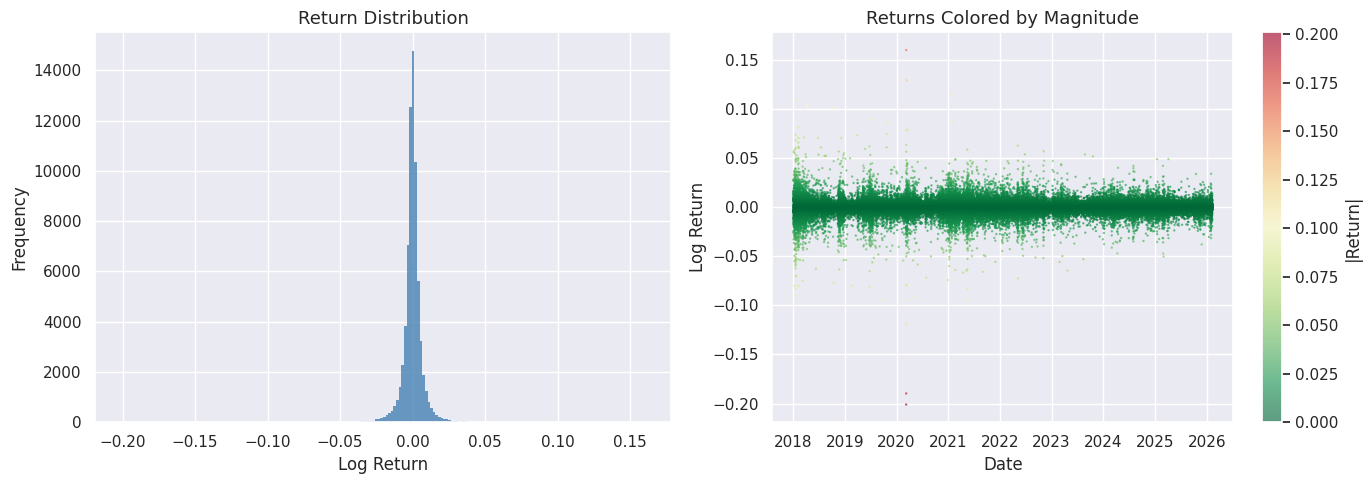

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['log_return'].dropna(), bins=200, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Return Distribution', fontsize=13)
axes[0].set_xlabel('Log Return')
axes[0].set_ylabel('Frequency')
# Return histogram

abs_ret = df['log_return'].abs()
sc = axes[1].scatter(df.index, df['log_return'], c=abs_ret, cmap='RdYlGn_r', s=0.5, alpha=0.6)
axes[1].set_title('Returns Colored by Magnitude', fontsize=13)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log Return')
plt.colorbar(sc, ax=axes[1], label='|Return|')
# Returns over time, colored by magnitude

plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/eda_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

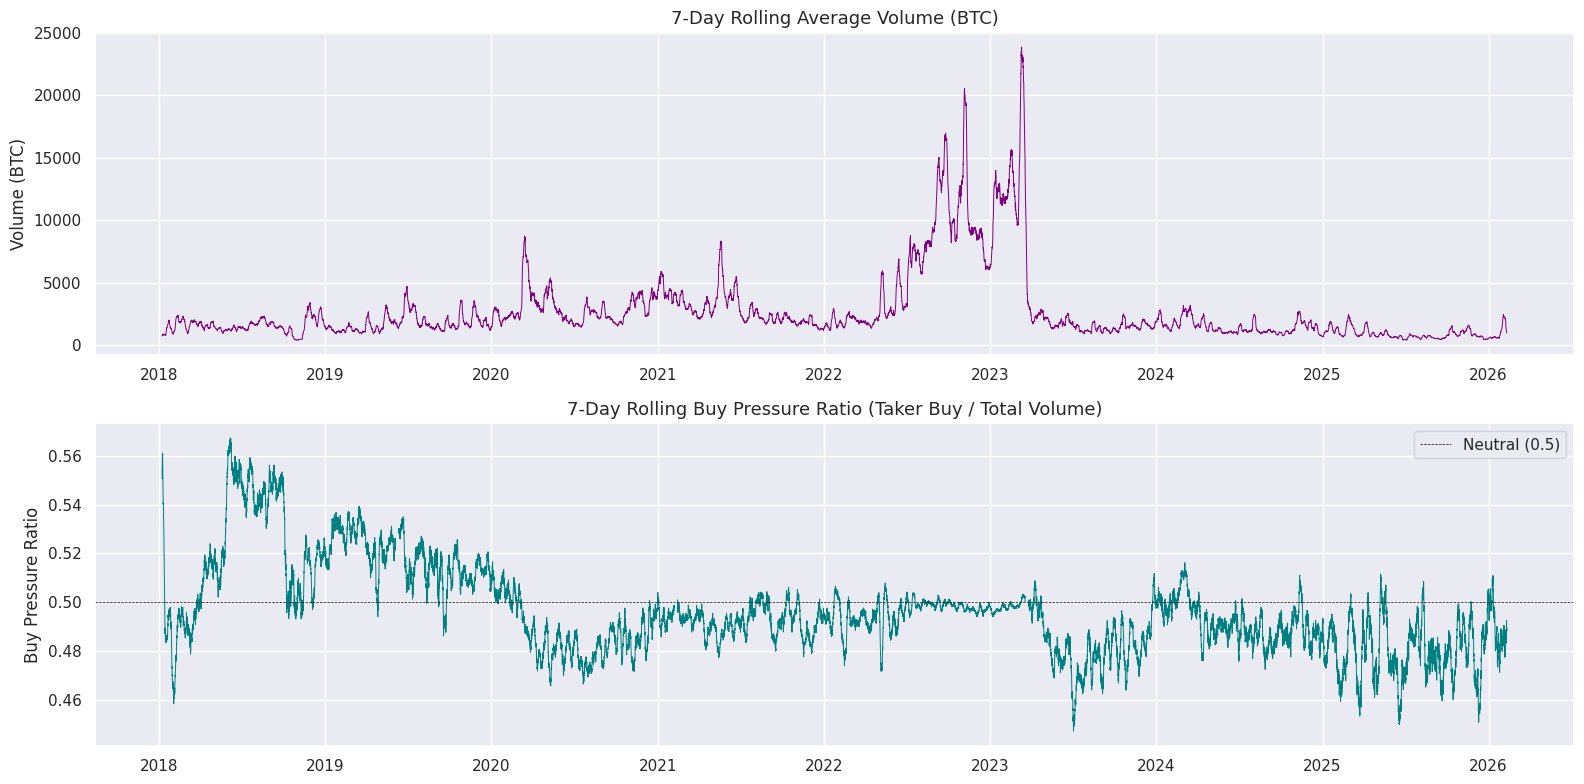

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

roll_vol_7d = df['volume'].rolling(BARS_PER_WEEK).mean()
axes[0].plot(df.index, roll_vol_7d, color='purple', linewidth=0.7)
axes[0].set_title('7-Day Rolling Average Volume (BTC)', fontsize=13)
axes[0].set_ylabel('Volume (BTC)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

df['buy_pressure_ratio'] = df['taker_buy_base_volume'] / df['volume'].replace(0, np.nan)
roll_pressure = df['buy_pressure_ratio'].rolling(BARS_PER_WEEK).mean()
axes[1].plot(df.index, roll_pressure, color='teal', linewidth=0.7)
axes[1].axhline(0.5, color='black', linewidth=0.5, linestyle='--', label='Neutral (0.5)')
axes[1].set_title('7-Day Rolling Buy Pressure Ratio (Taker Buy / Total Volume)', fontsize=13)
axes[1].set_ylabel('Buy Pressure Ratio')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/eda_volume_pressure.png', dpi=150, bbox_inches='tight')
plt.show()
# Volume and buy-pressure trends

In [ ]:
desc = df[['close', 'log_return', 'volume', 'num_trades']].describe().round(6)
desc.to_csv(f'{DIR_NOTES}/descriptive_statistics.csv')
print('Descriptive statistics saved.')
# Descriptive statistics for key columns

Descriptive statistics saved.


The next two cells compute the forward-looking realized-volatility targets that every model is scored against.

In [ ]:
def realized_vol_forward(returns, bars):
  squared = returns ** 2
  rv = squared[::-1].rolling(window=bars, min_periods=bars).sum()[::-1].shift(-(bars-1))
  return np.sqrt(rv)
# Forward-looking realized volatility over the next `bars` rows

df['future_1d_vol'] = realized_vol_forward(df['log_return'], BARS_PER_DAY)
df['future_1w_vol'] = realized_vol_forward(df['log_return'], BARS_PER_WEEK)
df['future_1m_vol'] = realized_vol_forward(df['log_return'], BARS_PER_MONTH)
# One target per horizon

for col in ['future_1d_vol', 'future_1w_vol', 'future_1m_vol']:
    n_valid = df[col].notna().sum()
# Count valid rows per target

assert (df['future_1d_vol'].dropna() >= 0).all(), 'Negative 1d vol found!'
assert (df['future_1w_vol'].dropna() >= 0).all(), 'Negative 1w vol found!'
assert (df['future_1m_vol'].dropna() >= 0).all(), 'Negative 1m vol found!'
# Sanity check: volatility must be non-negative

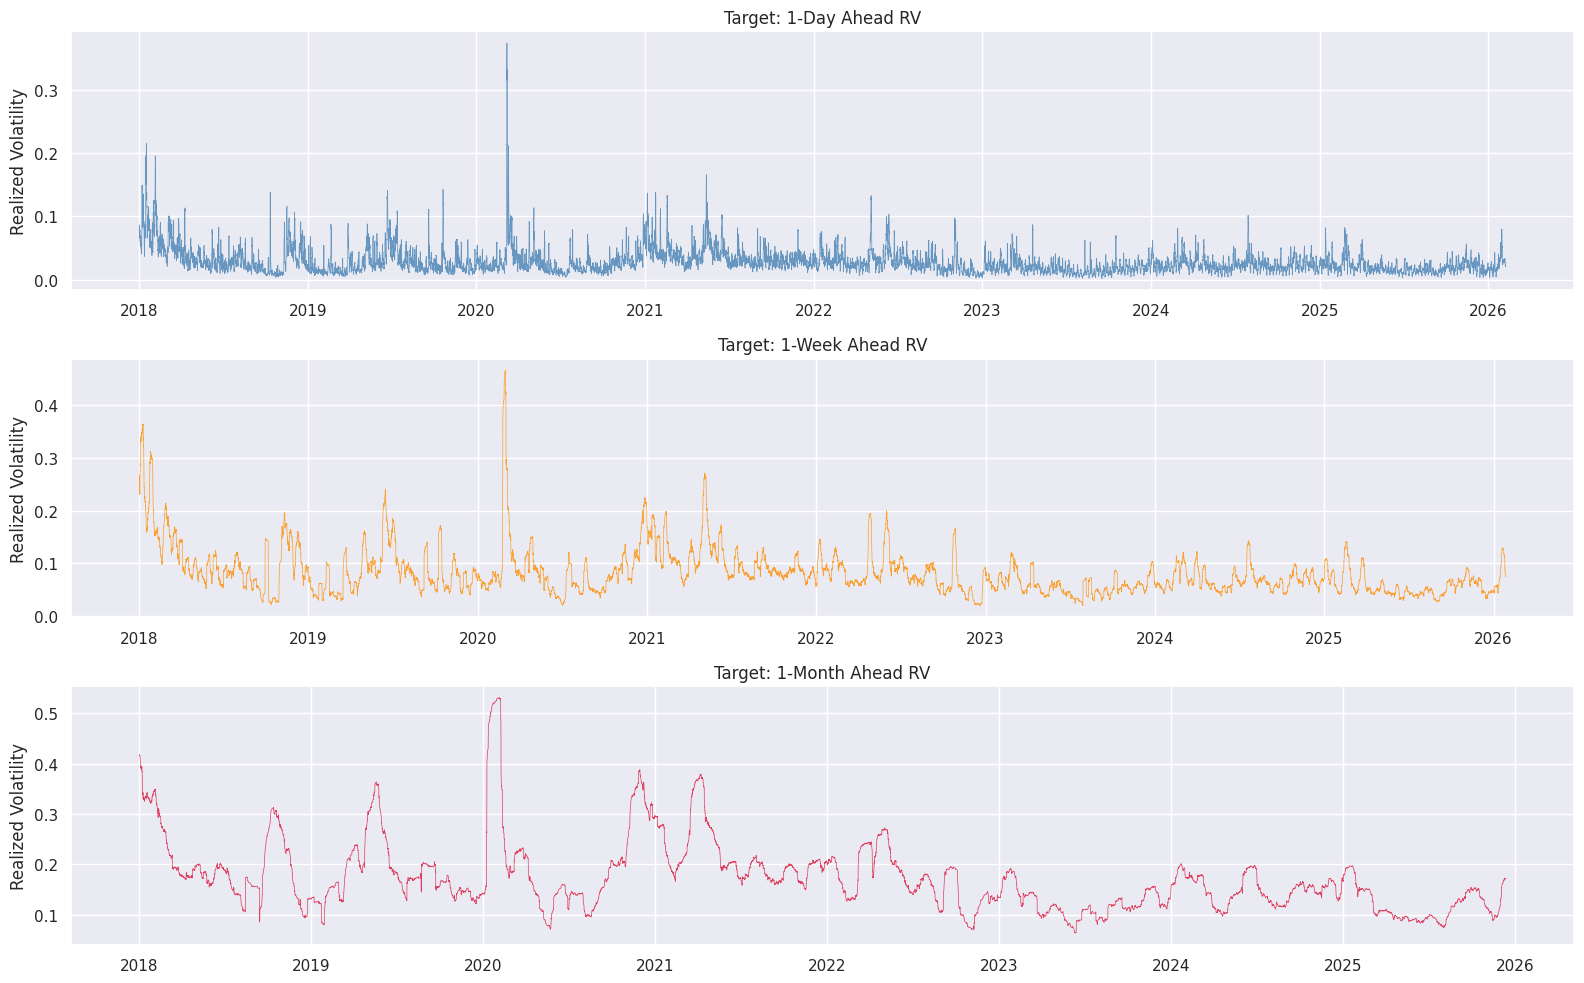

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
colors = ['steelblue', 'darkorange', 'crimson']
targets = ['future_1d_vol', 'future_1w_vol', 'future_1m_vol']
labels  = ['1-Day Ahead RV', '1-Week Ahead RV', '1-Month Ahead RV']

for ax, col, label, color in zip(axes, targets, labels, colors):
    ax.plot(df.index, df[col], color=color, linewidth=0.5, alpha=0.8)
    ax.set_title(f'Target: {label}', fontsize=12)
    ax.set_ylabel('Realized Volatility')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/targets_all_horizons.png', dpi=150, bbox_inches='tight')
plt.show()
# Plot the targets

In [ ]:
for lag in LAG_DEPTHS:
    df[f'ret_lag_{lag}h'] = df['log_return'].shift(lag)
# Lagged returns

past_rv_1d = df['log_return'].rolling(BARS_PER_DAY).apply(lambda x: np.sqrt(np.sum(x**2)), raw=True)
past_rv_1w = df['log_return'].rolling(BARS_PER_WEEK).apply(lambda x: np.sqrt(np.sum(x**2)), raw=True)
past_rv_1m = df['log_return'].rolling(BARS_PER_MONTH).apply(lambda x: np.sqrt(np.sum(x**2)), raw=True)
# Backward-looking realized volatility over each horizon

df['past_rv_1d'] = past_rv_1d.shift(1)
df['past_rv_1w'] = past_rv_1w.shift(1)
df['past_rv_1m'] = past_rv_1m.shift(1)
# Shift by one bar to prevent leakage

for w in ROLLING_WINDOWS:
    df[f'roll_mean_ret_{w}h'] = df['log_return'].rolling(w).mean().shift(1)
    df[f'roll_std_ret_{w}h'] = df['log_return'].rolling(w).std().shift(1)
    df[f'roll_skew_ret_{w}h'] = df['log_return'].rolling(w).skew().shift(1)
    df[f'roll_kurt_ret_{w}h'] = df['log_return'].rolling(w).kurt().shift(1)
# Rolling return statistics:
#   mean: recent trend
#   std:  recent volatility level
#   skew: directional asymmetry
#   kurt: tail risk / large moves

In [ ]:
for lag in [1, 6, 24, 168]:
    df[f'vol_lag_{lag}h'] = df['volume'].shift(lag)
    df[f'trades_lag_{lag}h'] = df['num_trades'].shift(lag)
# Lagged volume and trade counts

df['vol_change_1h']  = (df['volume'] / df['volume'].shift(1).replace(0, np.nan)).shift(1)
df['vol_change_24h'] = (df['volume'] / df['volume'].shift(24).replace(0, np.nan)).shift(1)
for w in [24, 168, 720]:
    df[f'roll_avg_vol_{w}h'] = df['volume'].rolling(w).mean().shift(1)
# Volume change ratios (>1 means growth; zero volume is treated as missing) and rolling averages

In [ ]:
df['buy_share'] = (df['taker_buy_base_volume'] / df['volume'].replace(0, np.nan)).shift(1)
# Taker-buy share of volume, shifted to use only past data

df['buy_sell_imbalance'] = ((df['taker_buy_base_volume'] - (df['volume'] - df['taker_buy_base_volume']))
                             / df['volume'].replace(0, np.nan)).shift(1)
# Buy/sell imbalance, shifted for the same reason

df['roll_buy_pressure_24h']  = df['buy_share'].shift(1).rolling(24).mean()
df['roll_buy_pressure_168h'] = df['buy_share'].shift(1).rolling(168).mean()
for lag in [1, 24]:
    df[f'taker_buy_usd_lag_{lag}h'] = df['taker_buy_quote_volume'].shift(lag)
# Rolling buy pressure and lagged taker-buy USD volume

In [ ]:
df['hl_range'] = ((df['high'] - df['low']) / df['close'].replace(0, np.nan)).shift(1)
for w in [24, 168]:
    df[f'roll_hl_range_{w}h'] = df['hl_range'].shift(1).rolling(w).mean()
df['hour_of_day'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
print(f'Total columns in df now: {df.shape[1]}')
print(f'Every column in df now: {df.columns.tolist()}')

# Intrabar range and cyclical time encodings

Total columns in df now: 73
Every column in df now: ['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume', 'num_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume', 'log_return', 'buy_pressure_ratio', 'future_1d_vol', 'future_1w_vol', 'future_1m_vol', 'ret_lag_1h', 'ret_lag_2h', 'ret_lag_3h', 'ret_lag_6h', 'ret_lag_12h', 'ret_lag_24h', 'ret_lag_48h', 'ret_lag_168h', 'past_rv_1d', 'past_rv_1w', 'past_rv_1m', 'roll_mean_ret_24h', 'roll_std_ret_24h', 'roll_skew_ret_24h', 'roll_kurt_ret_24h', 'roll_mean_ret_48h', 'roll_std_ret_48h', 'roll_skew_ret_48h', 'roll_kurt_ret_48h', 'roll_mean_ret_168h', 'roll_std_ret_168h', 'roll_skew_ret_168h', 'roll_kurt_ret_168h', 'roll_mean_ret_336h', 'roll_std_ret_336h', 'roll_skew_ret_336h', 'roll_kurt_ret_336h', 'roll_mean_ret_720h', 'roll_std_ret_720h', 'roll_skew_ret_720h', 'roll_kurt_ret_720h', 'vol_lag_1h', 'trades_lag_1h', 'vol_lag_6h', 'trades_lag_6h', 'vol_lag_24h', 'trades_lag_24h', 'vol_lag_168h', 'trades_lag_168h', 'vol_change_1h'

In [ ]:
TARGET_COLS  = ['future_1d_vol', 'future_1w_vol', 'future_1m_vol']
RAW_COLS     = ['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume',
                'num_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume',
                'log_return', 'buy_pressure_ratio', 'hour_of_day', 'day_of_week']
FEATURE_COLS = [c for c in df.columns if c not in TARGET_COLS + RAW_COLS]
def categorize(col):
    if 'ret_lag' in col: return 'return_lag'
    if 'past_rv' in col: return 'volatility_lag'
    if 'roll_'in col and 'ret' in col: return 'rolling_return_stat'
    if 'roll_avg_vol'in col or 'vol_lag' in col or 'vol_change' in col or 'trades' in col: return 'volume_activity'
    if 'buy' in col or 'taker' in col or 'imbalance' in col: return 'market_pressure'
    if 'hl_range' in col: return 'price_range'
    if 'hour' in col or 'dow' in col: return 'time_cyclical'
    return 'other'
# Group features by category
manifest = pd.DataFrame({
    'feature': FEATURE_COLS,
    'category': [categorize(c) for c in FEATURE_COLS]})
manifest.to_csv(f'{DIR_NOTES}/feature_manifest.csv', index=False)
check_cols = FEATURE_COLS + TARGET_COLS
df_model = df.dropna(subset=check_cols).copy()

In [ ]:
train_df = df_model[df_model.index <  VAL_START].copy()
val_df = df_model[(df_model.index >= VAL_START) & (df_model.index < TEST_START)].copy()
test_df = df_model[df_model.index >= TEST_START].copy()
print(f'Train: {len(train_df):,} rows')
print(f'Val: {len(val_df):,} rows')
print(f'Test: {len(test_df):,} rows')
X_train = train_df[FEATURE_COLS]
X_val = val_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]
y_train = {h: train_df[f'future_{h}_vol'] for h in HORIZONS}
y_val = {h: val_df[f'future_{h}_vol']   for h in HORIZONS}
y_test = {h: test_df[f'future_{h}_vol']  for h in HORIZONS}
# Chronological split

Train: 42,765 rows
Val: 8,591 rows
Test: 17,064 rows


In [ ]:
def get_walkforward_windows(df_full, train_start, val_start, test_start,
                             step_days=30, max_window_days=365):
    windows = []
    current_val_start = pd.Timestamp(val_start)
    current_val_end = current_val_start + pd.Timedelta(days=step_days)
    absolute_train_start = pd.Timestamp(train_start)
    test_boundary = pd.Timestamp(test_start)

    while current_val_end <= test_boundary:
        train_window_days = (current_val_start - absolute_train_start).days

        if train_window_days <= max_window_days:
            current_train_start = absolute_train_start
            #Expanding window
        else:
            current_train_start = current_val_start - pd.Timedelta(days=max_window_days)
            #Fixed rolling window and drops the oldest data

        train_mask = (df_full.index >= current_train_start) & (df_full.index < current_val_start)
        val_mask   = (df_full.index >= current_val_start)   & (df_full.index < current_val_end)
        if train_mask.sum() > 0 and val_mask.sum() > 0:
            windows.append({
                'train_start': current_train_start,
                'train_end': current_val_start,
                'val_start': current_val_start,
                'val_end': current_val_end,
                'mode': 'expanding' if train_window_days <= max_window_days else 'fixed',
                'train_idx': df_full.index[train_mask],
                'val_idx': df_full.index[val_mask]
            })
        current_val_start = current_val_end
        current_val_end   = current_val_start + pd.Timedelta(days=step_days)
        # Assign rows to the window, then advance 30 days

    return windows

wf_windows = get_walkforward_windows(
    df_model, TRAIN_START, VAL_START, TEST_START,
    step_days=WF_STEP_DAYS, max_window_days=WF_MAX_WINDOW_DAYS
)

print(f'Total walk forward windows:{len(wf_windows)}')
expand = sum(1 for w in wf_windows if w['mode'] == 'expanding')
fixed  = sum(1 for w in wf_windows if w['mode'] == 'fixed')
print(f'Expanding windows: {expand} | Fixed windows: {fixed}')


Total walk forward windows:12
Expanding windows: 0 | Fixed windows: 12


In [ ]:
naive_preds = {}
for h in HORIZONS:
    target_col = f'future_{h}_vol'
    if h == '1d':
        naive_forecast = test_df['past_rv_1d']
    elif h == '1w':
        naive_forecast = test_df['past_rv_1w']
    else:
        naive_forecast = test_df['past_rv_1m']
    # Persistence baseline: next period's volatility equals the most recent realized volatility

    naive_preds[h] = pd.DataFrame({
        'timestamp' : test_df.index,
        'actual' : test_df[target_col].values,
        'predicted' : naive_forecast.values,
        'model' : 'naive_persistence',
        'horizon': h
    }).dropna()
    out_path = f'{DIR_PREDS}/naive_{h}_predictions.csv'
    naive_preds[h].to_csv(out_path, index=False)
    print(f'Saved naive predictions to {out_path}')
    # Same prediction schema used by every model

Saved naive predictions to outputs/predictions/naive_1d_predictions.csv
Saved naive predictions to outputs/predictions/naive_1w_predictions.csv
Saved naive predictions to outputs/predictions/naive_1m_predictions.csv


In [ ]:
from arch import arch_model
RETURN_SCALE = 100
def fit_garch(return_series):
  model = arch_model(
      return_series * RETURN_SCALE,
      vol='GARCH', p=1, q=1,
      dist='StudentsT',
      rescale=False)
  result = model.fit(disp='off', show_warning=False)
  return result
  # GARCH(1,1) with Student-t errors to capture heavy tails

def garch_forecast_vol(garch_result, horizon_bars):
    fc = garch_result.forecast(horizon=horizon_bars, reindex=False)
    variance_sum = fc.variance.iloc[-1].sum()
    return np.sqrt(variance_sum) / RETURN_SCALE
    # Multi-step forecast: sqrt of summed variances over the horizon

train_returns = df_model.loc[df_model.index < VAL_START, 'log_return']
print(f'\nInitial GARCH fit on {len(train_returns):,} training observations...')
garch_fit = fit_garch(train_returns)
print(f'AIC: {garch_fit.aic:.2f} | BIC:{garch_fit.bic:.2f}')
print(garch_fit.summary().tables[1])
# AIC / BIC of the initial fit


Initial GARCH fit on 42,765 training observations...
AIC: 70575.97 | BIC:70619.29
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         6.4837e-03  1.713e-03      3.784  1.543e-04 [3.125e-03,9.842e-03]


In [ ]:
garch_preds = {h: [] for h in HORIZONS}
horizon_bars = {'1d': BARS_PER_DAY, '1w': BARS_PER_WEEK, '1m': BARS_PER_MONTH}
test_timestamps = test_df.index
last_refit_date = pd.Timestamp(TEST_START)
current_garch = garch_fit
# Start from the training-period fit

for i, ts in enumerate(test_timestamps):
    days_since_refit = (ts - last_refit_date).days
    if days_since_refit >= GARCH_REFIT_DAYS:
        returns_up_to_now = df_model.loc[df_model.index < ts, 'log_return']
        try:
            current_garch = fit_garch(returns_up_to_now)
            last_refit_date = ts
        except Exception as e:
            print(f'GARCH refit failed at {ts}: {e} — using prior fit.')


    for h in HORIZONS:
        try:
            vol_forecast = garch_forecast_vol(current_garch, horizon_bars[h])
        except Exception:
            vol_forecast = np.nan
        garch_preds[h].append({
            'timestamp': ts,
            'actual': test_df.loc[ts, f'future_{h}_vol'],
            'predicted': vol_forecast,
            'model': 'garch',
            'horizon': h
        })
    if i % 1000 == 0:
        print(f'Progress: {i}/{len(test_timestamps)} rows processed...')
# Forecast every horizon for each test hour

for h in HORIZONS:
    df_garch = pd.DataFrame(garch_preds[h]).dropna()
    df_garch.to_csv(f'{DIR_PREDS}/garch_{h}_predictions.csv', index=False)
    print(f'GARCH {h}: {len(df_garch)} predictions saved.')


Progress: 0/17064 rows processed...
Progress: 1000/17064 rows processed...
Progress: 2000/17064 rows processed...
Progress: 3000/17064 rows processed...
Progress: 4000/17064 rows processed...
Progress: 5000/17064 rows processed...
Progress: 6000/17064 rows processed...
Progress: 7000/17064 rows processed...
Progress: 8000/17064 rows processed...
Progress: 9000/17064 rows processed...
Progress: 10000/17064 rows processed...
Progress: 11000/17064 rows processed...
Progress: 12000/17064 rows processed...
Progress: 13000/17064 rows processed...
Progress: 14000/17064 rows processed...
Progress: 15000/17064 rows processed...
Progress: 16000/17064 rows processed...
Progress: 17000/17064 rows processed...
GARCH 1d: 17064 predictions saved.
GARCH 1w: 17064 predictions saved.
GARCH 1m: 17064 predictions saved.


In [ ]:
from xgboost import XGBRegressor
import joblib
xgb_models = {}
xgb_preds = {}
for h in HORIZONS:
  print(f'n   Horizon: {h}')
  y_tr = y_train[h]
  y_vl = y_val[h]
  y_te = y_test[h]
  model = XGBRegressor(**XGB_PARAMS)
  model.fit(X_train, y_tr, eval_set=[(X_val, y_vl)], verbose = 50)
  # verbose controls how often training progress prints

  preds = model.predict(X_test)
  xgb_preds[h] = pd.DataFrame({
      'timestamp' : test_df.index,
      'actual'    : y_te.values,
      'predicted' : preds,
      'model'     : 'xgboost',
      'horizon'   : h
  })
  # Save predictions and model
  xgb_preds[h].to_csv(f'{DIR_PREDS}/xgb_{h}_predictions.csv', index=False)
  joblib.dump(model, f'{DIR_MODELS}/xgb_{h}.pkl')
  xgb_models[h] = model
  best_iter = model.best_iteration
  print(f'   Best iteration: {best_iter}')

n   Horizon: 1d
[0]	validation_0-rmse:0.01693
[50]	validation_0-rmse:0.01220
[64]	validation_0-rmse:0.01246
   Best iteration: 34
n   Horizon: 1w
[0]	validation_0-rmse:0.03697
[50]	validation_0-rmse:0.02583
[52]	validation_0-rmse:0.02572
   Best iteration: 22
n   Horizon: 1m
[0]	validation_0-rmse:0.07819
[31]	validation_0-rmse:0.08201
   Best iteration: 1


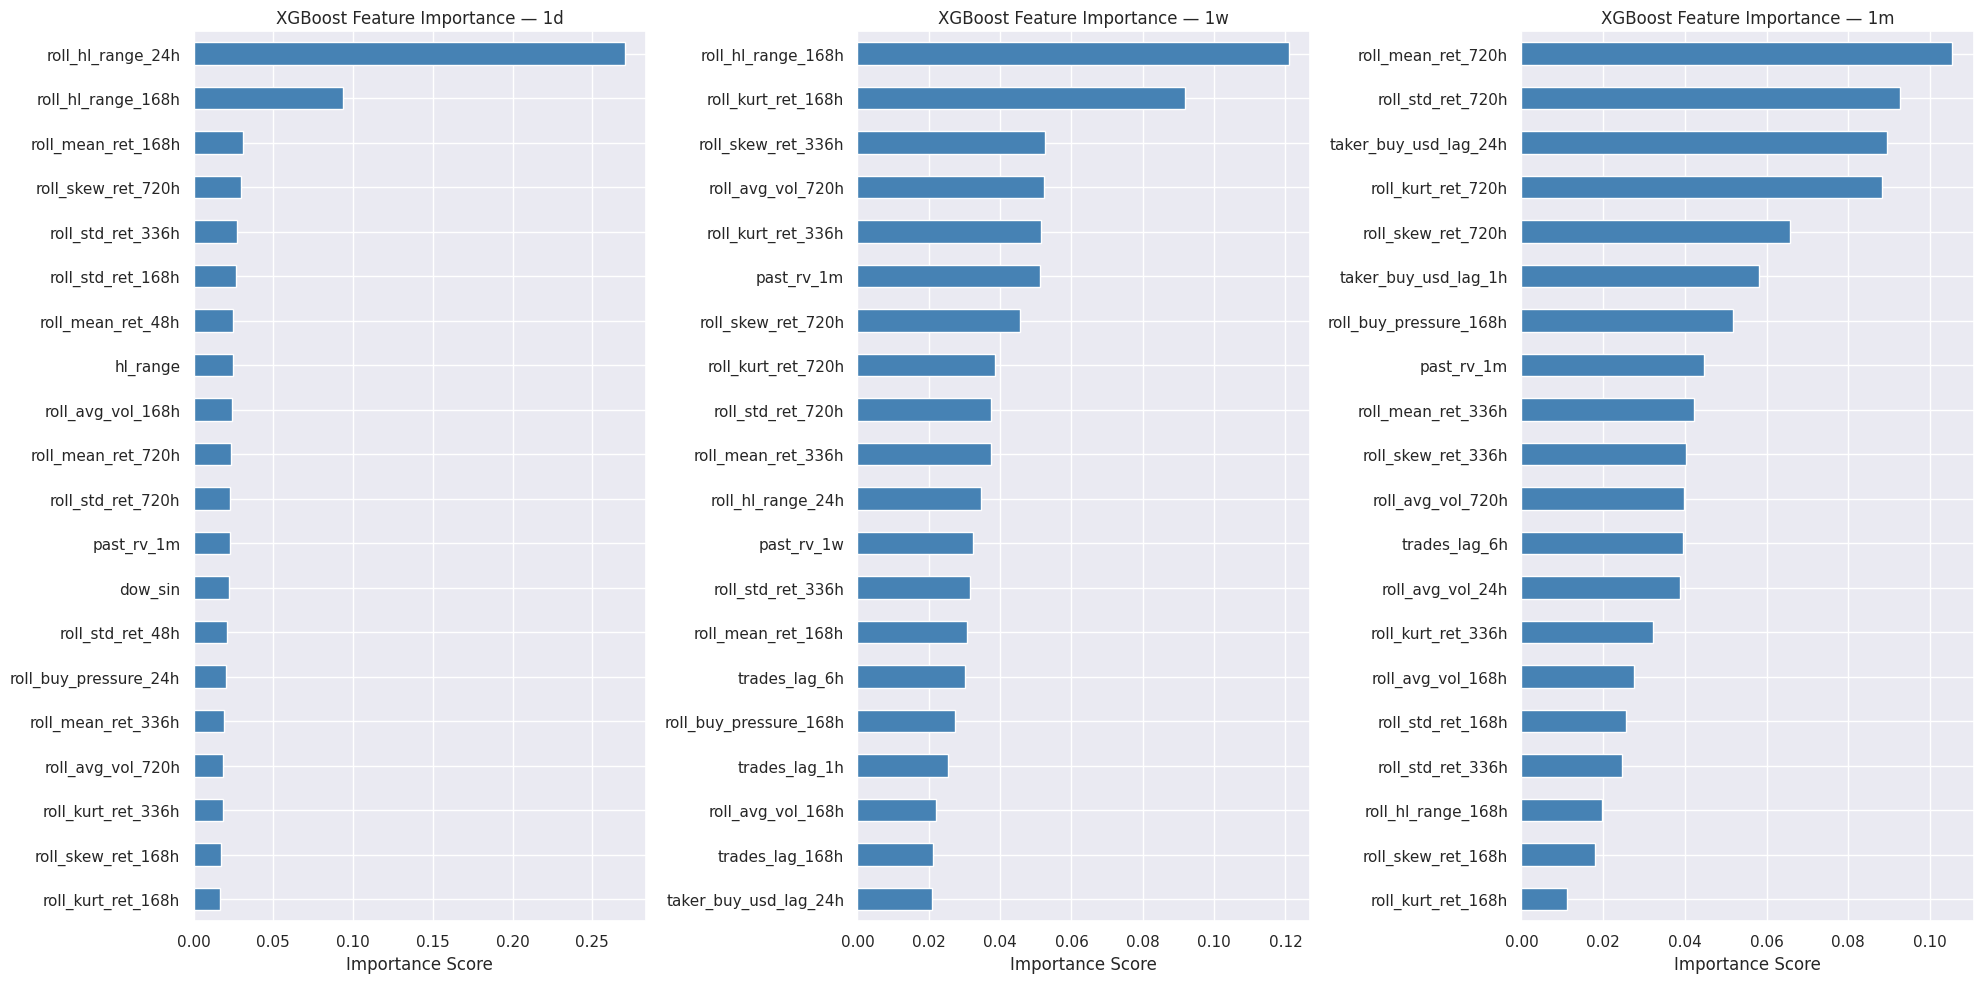

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for ax, h in zip(axes, HORIZONS):
    model = xgb_models[h]
    importance = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    top20 = importance.nlargest(20)
    top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'XGBoost Feature Importance — {h}', fontsize=12)
    ax.set_xlabel('Importance Score')
    importance.sort_values(ascending=False).to_csv(
        f'{DIR_METRICS}/xgb_feature_importance_{h}.csv', header=['importance']
    )
plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/xgb_feature_importance_all_horizons.png', dpi=150, bbox_inches='tight')
plt.show()
# Top-20 feature importance per horizon

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats

def evaluate_predictions(actual, predicted, model_name, horizon):
    mask   = ~(np.isnan(actual) | np.isnan(predicted))
    actual = np.array(actual)[mask]
    predicted = np.array(predicted)[mask]
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    return {
        'model'  : model_name,
        'horizon': horizon,
        'n_obs'  : len(actual),
        'rmse'   : round(rmse, 8),
        'mae'    : round(mae, 8)
    }

def mincer_zarnowitz(actual, predicted):
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a, p = np.array(actual)[mask], np.array(predicted)[mask]
    slope, intercept, r, _, _ = stats.linregress(p, a)
    return round(intercept, 6), round(slope, 6), round(r**2, 6)
    # Mincer-Zarnowitz: regress actual on predicted to measure bias.
    # A perfect forecast has intercept 0 and slope 1.
    # Intercept above 0 means the model under-predicts.
    # Slope below 1 means the model under-reacts.

def diebold_mariano(actual, pred1, pred2, h=1):
    mask = ~(np.isnan(actual) | np.isnan(pred1) | np.isnan(pred2))
    a, p1, p2 = np.array(actual)[mask], np.array(pred1)[mask], np.array(pred2)[mask]
    e1 = (a - p1) ** 2
    e2 = (a - p2) ** 2
    d  = e1 - e2
    n  = len(d)
    d_bar   = np.mean(d)
    gamma0  = np.var(d, ddof=1)
    dm_stat = d_bar / np.sqrt(gamma0 / n)
    p_val   = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return round(dm_stat, 4), round(p_val, 4)
    # Diebold-Mariano: tests whether an accuracy gap between two models is statistically significant,
    # e.g. whether an RMSE of 0.0042 vs 0.0051 reflects a real difference
    # or could be explained by chance.

In [ ]:
all_metrics = []
mz_results  = []
dm_results  = []
for h in HORIZONS:
    naive_df = pd.read_csv(f'{DIR_PREDS}/naive_{h}_predictions.csv')
    garch_df = pd.read_csv(f'{DIR_PREDS}/garch_{h}_predictions.csv')
    xgb_df = pd.read_csv(f'{DIR_PREDS}/xgb_{h}_predictions.csv')
    # Load saved predictions

    common_ts = set(naive_df['timestamp']) & set(garch_df['timestamp']) & set(xgb_df['timestamp'])
    naive_df = naive_df[naive_df['timestamp'].isin(common_ts)].sort_values('timestamp').reset_index(drop=True)
    garch_df = garch_df[garch_df['timestamp'].isin(common_ts)].sort_values('timestamp').reset_index(drop=True)
    xgb_df = xgb_df[xgb_df['timestamp'].isin(common_ts)].sort_values('timestamp').reset_index(drop=True)
    actual = xgb_df['actual'].values
    # Align on shared timestamps

    for name, preds_df in [('naive', naive_df), ('garch', garch_df), ('xgboost', xgb_df)]:
        m = evaluate_predictions(actual, preds_df['predicted'].values, name, h)
        all_metrics.append(m)
    #RMSE / MAE

    for name, preds_df in [('naive', naive_df), ('garch', garch_df), ('xgboost', xgb_df)]:
        alpha, beta, r2 = mincer_zarnowitz(actual, preds_df['predicted'].values)
        mz_results.append({'model': name, 'horizon': h, 'mz_alpha': alpha, 'mz_beta': beta, 'mz_r2': r2})
    #Mincer-Zarnowitz

    dm_xgb_garch = diebold_mariano(actual, xgb_df['predicted'].values, garch_df['predicted'].values)
    dm_xgb_naive = diebold_mariano(actual, xgb_df['predicted'].values, naive_df['predicted'].values)
    dm_results.append({'horizon': h, 'comparison': 'XGB vs GARCH', 'dm_stat': dm_xgb_garch[0], 'p_value': dm_xgb_garch[1]})
    dm_results.append({'horizon': h, 'comparison': 'XGB vs Naive', 'dm_stat': dm_xgb_naive[0], 'p_value': dm_xgb_naive[1]})
    #Diebold-Mariano: XGBoost vs GARCH, XGBoost vs Naive

metrics_df = pd.DataFrame(all_metrics)
mz_df = pd.DataFrame(mz_results)
dm_df = pd.DataFrame(dm_results)
metrics_df.to_csv(f'{DIR_METRICS}/metrics_summary.csv', index=False)
mz_df.to_csv(f'{DIR_METRICS}/mincer_zarnowitz.csv', index=False)
dm_df.to_csv(f'{DIR_METRICS}/diebold_mariano.csv', index=False)
pivot = metrics_df.pivot_table(index='model', columns='horizon', values=['rmse','mae'])
print(pivot.round(6))

              mae                          rmse                    
horizon        1d        1m        1w        1d        1m        1w
model                                                              
garch    0.011525  0.144791  0.032508  0.015800  0.158423  0.040536
naive    0.010737  0.035086  0.019515  0.014478  0.043410  0.026994
xgboost  0.011381  0.065245  0.033324  0.014194  0.073376  0.043175


In [ ]:
print('\n Mincer-Zarnowitz Results')
print('(Perfect forecast: alpha=0, beta=1)')
print(mz_df.to_string(index=False))
print('\n Diebold-Mariano Results')
print('(p < 0.05 = statistically significant difference in accuracy)')
print(dm_df.to_string(index=False))


 Mincer-Zarnowitz Results
(Perfect forecast: alpha=0, beta=1)
  model horizon  mz_alpha   mz_beta    mz_r2
  naive      1d  0.017538  0.229606 0.052626
  garch      1d  0.017564  0.189995 0.039702
xgboost      1d  0.013264  0.318898 0.033814
  naive      1w  0.052137  0.179817 0.033095
  garch      1w  0.048510  0.167268 0.045011
xgboost      1w  0.096727 -0.365907 0.125896
  naive      1m  0.122904  0.088579 0.007515
  garch      1m  0.151794 -0.060477 0.010837
xgboost      1m  0.131273  0.018444 0.000033

 Diebold-Mariano Results
(p < 0.05 = statistically significant difference in accuracy)
horizon   comparison   dm_stat  p_value
     1d XGB vs GARCH  -11.4757   0.0000
     1d XGB vs Naive   -2.6007   0.0093
     1w XGB vs GARCH    7.0542   0.0000
     1w XGB vs Naive   45.7341   0.0000
     1m XGB vs GARCH -132.0464   0.0000
     1m XGB vs Naive   88.9126   0.0000


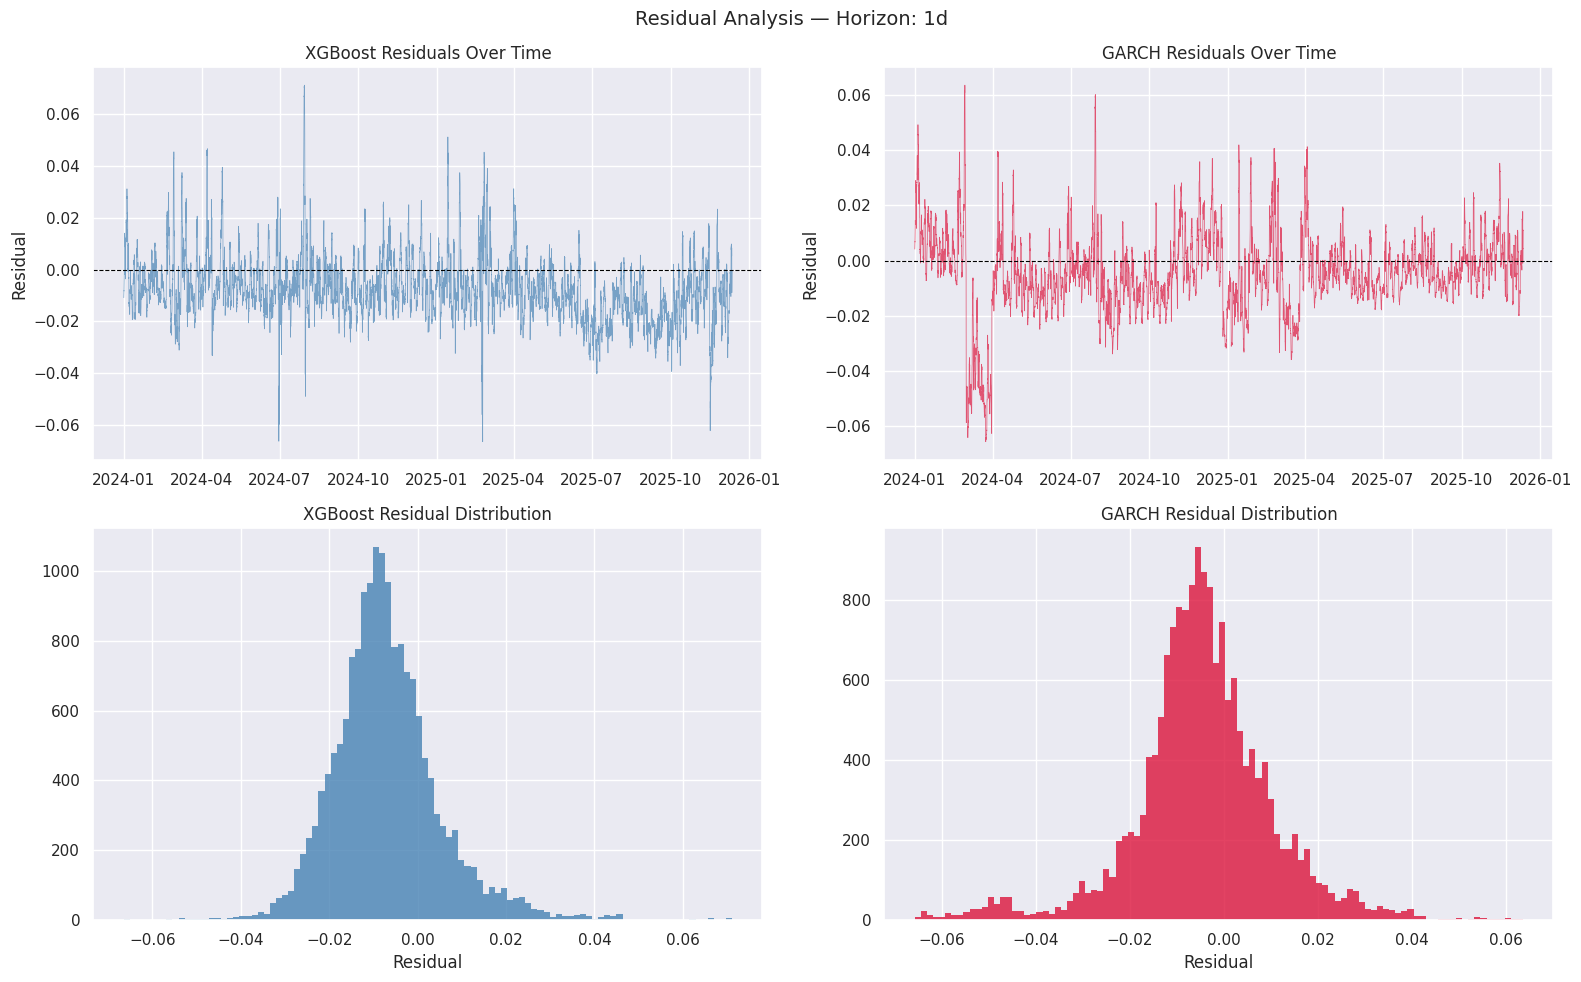

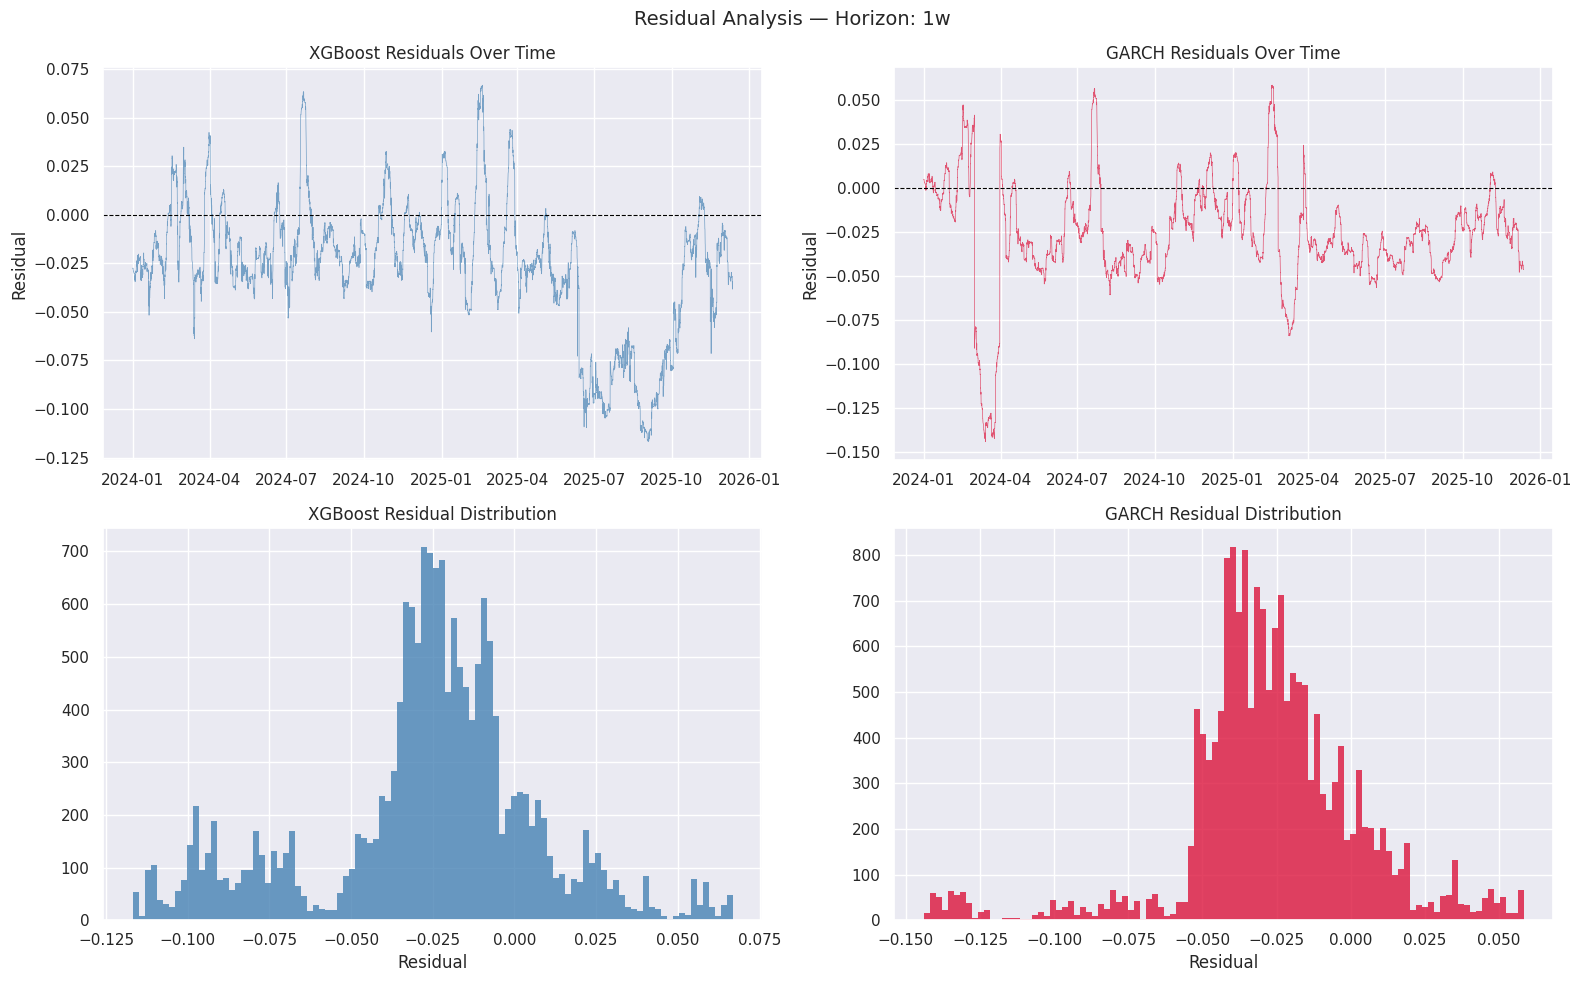

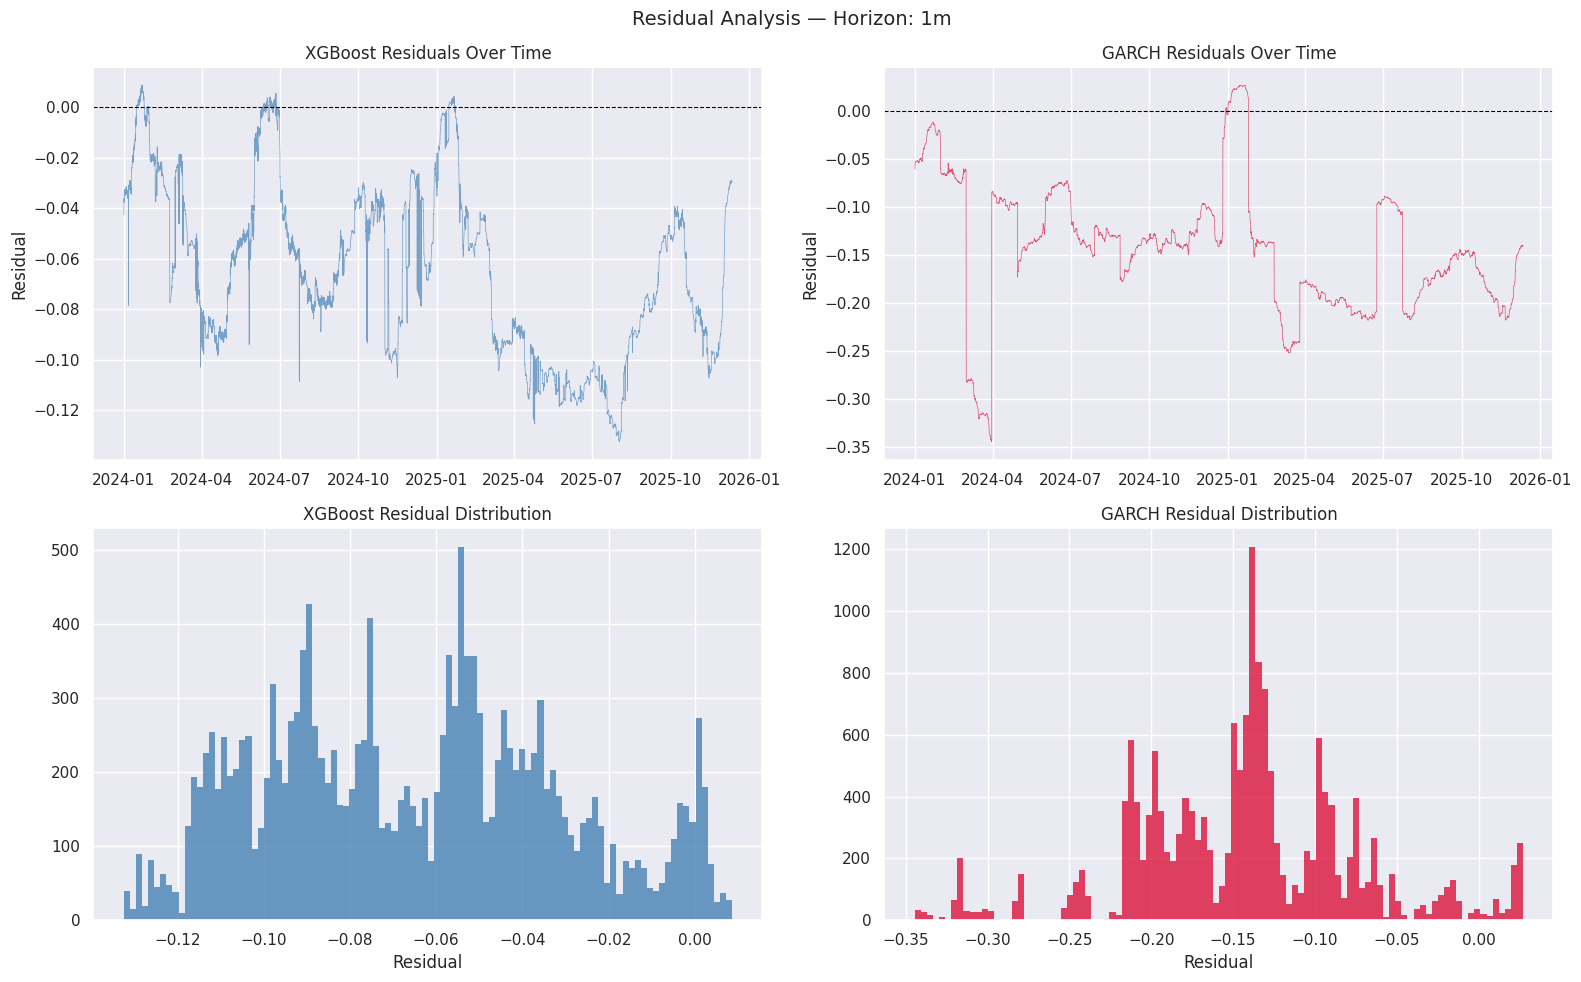

In [ ]:
for h in HORIZONS:
    xgb_df  = pd.read_csv(f'{DIR_PREDS}/xgb_{h}_predictions.csv')
    garch_df = pd.read_csv(f'{DIR_PREDS}/garch_{h}_predictions.csv')
    xgb_df['timestamp']   = pd.to_datetime(xgb_df['timestamp'])
    garch_df['timestamp'] = pd.to_datetime(garch_df['timestamp'])
    xgb_resid   = xgb_df['actual'] - xgb_df['predicted']
    garch_resid = garch_df['actual'] - garch_df['predicted']
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Residual Analysis — Horizon: {h}', fontsize=14)

    axes[0, 0].plot(xgb_df['timestamp'], xgb_resid, color='steelblue', linewidth=0.5, alpha=0.7)
    axes[0, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0, 0].set_title('XGBoost Residuals Over Time')
    axes[0, 0].set_ylabel('Residual')
    # XGBoost residuals over time

    axes[0, 1].plot(garch_df['timestamp'], garch_resid, color='crimson', linewidth=0.5, alpha=0.7)
    axes[0, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[0, 1].set_title('GARCH Residuals Over Time')
    axes[0, 1].set_ylabel('Residual')
    # GARCH residuals over time

    axes[1, 0].hist(xgb_resid.dropna(), bins=100, color='steelblue', alpha=0.8, edgecolor='none')
    axes[1, 0].set_title('XGBoost Residual Distribution')
    axes[1, 0].set_xlabel('Residual')
    # XGBoost residual distribution

    axes[1, 1].hist(garch_resid.dropna(), bins=100, color='crimson', alpha=0.8, edgecolor='none')
    axes[1, 1].set_title('GARCH Residual Distribution')
    axes[1, 1].set_xlabel('Residual')
    # GARCH residual distribution

    plt.tight_layout()
    plt.savefig(f'{DIR_FIGURES}/residuals_{h}.png', dpi=150, bbox_inches='tight')
    plt.show()

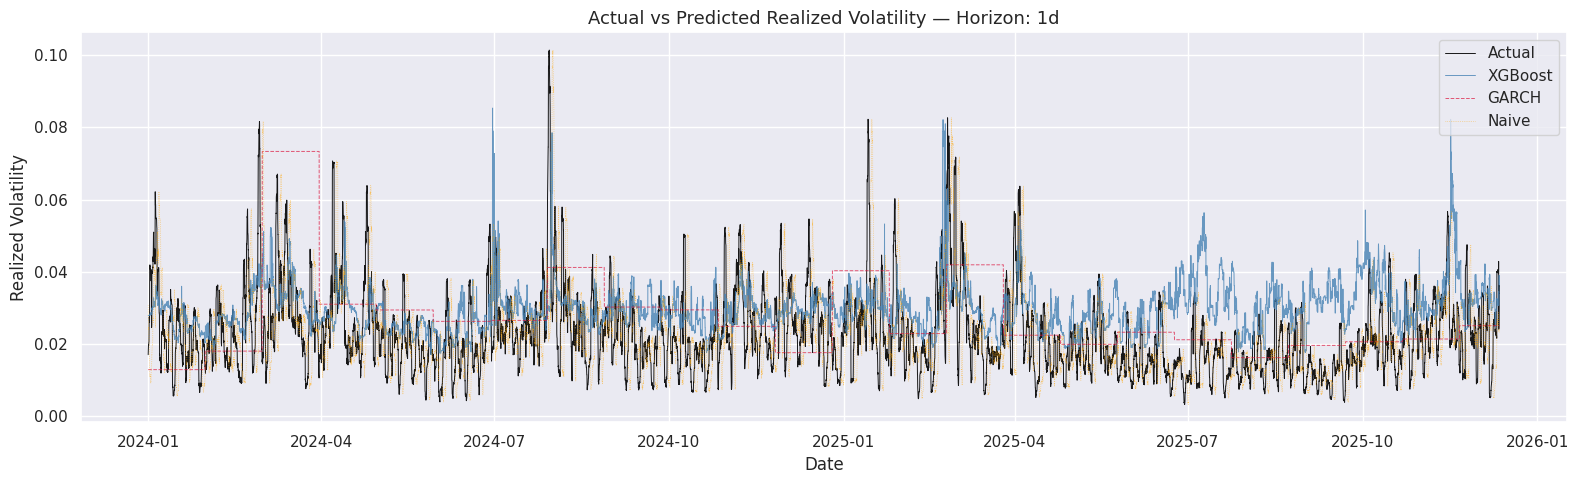

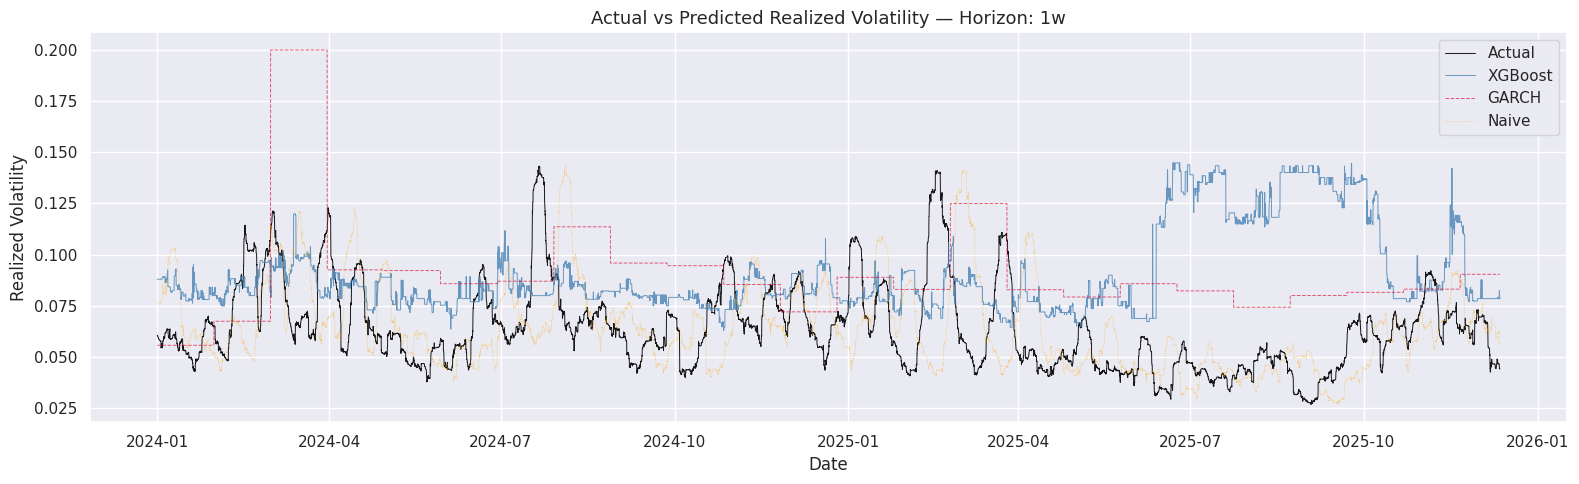

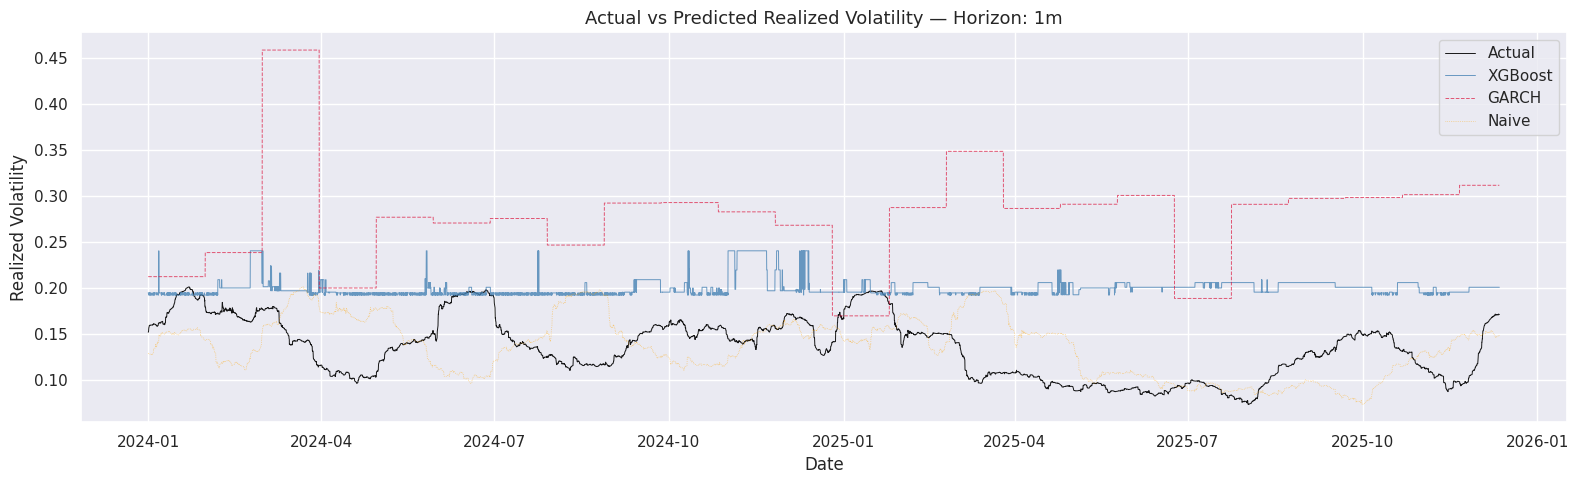

In [ ]:
for h in HORIZONS:
    naive_df = pd.read_csv(f'{DIR_PREDS}/naive_{h}_predictions.csv')
    garch_df = pd.read_csv(f'{DIR_PREDS}/garch_{h}_predictions.csv')
    xgb_df = pd.read_csv(f'{DIR_PREDS}/xgb_{h}_predictions.csv')

    for df_ in [naive_df, garch_df, xgb_df]:
        df_['timestamp'] = pd.to_datetime(df_['timestamp'])

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(xgb_df['timestamp'], xgb_df['actual'],color='black', linewidth=0.7, label='Actual', alpha=0.9)
    ax.plot(xgb_df['timestamp'], xgb_df['predicted'], color='steelblue', linewidth=0.7, label='XGBoost', alpha=0.8)
    ax.plot(garch_df['timestamp'], garch_df['predicted'], color='crimson', linewidth=0.7, label='GARCH', alpha=0.7, linestyle='--')
    ax.plot(naive_df['timestamp'], naive_df['predicted'], color='orange', linewidth=0.5, label='Naive', alpha=0.6, linestyle=':')

    ax.set_title(f'Actual vs Predicted Realized Volatility — Horizon: {h}', fontsize=13)
    ax.set_ylabel('Realized Volatility')
    ax.set_xlabel('Date')
    ax.legend(loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()
    plt.savefig(f'{DIR_FIGURES}/actual_vs_predicted_{h}.png', dpi=150, bbox_inches='tight')
    plt.show()
    # Actual vs predicted volatility

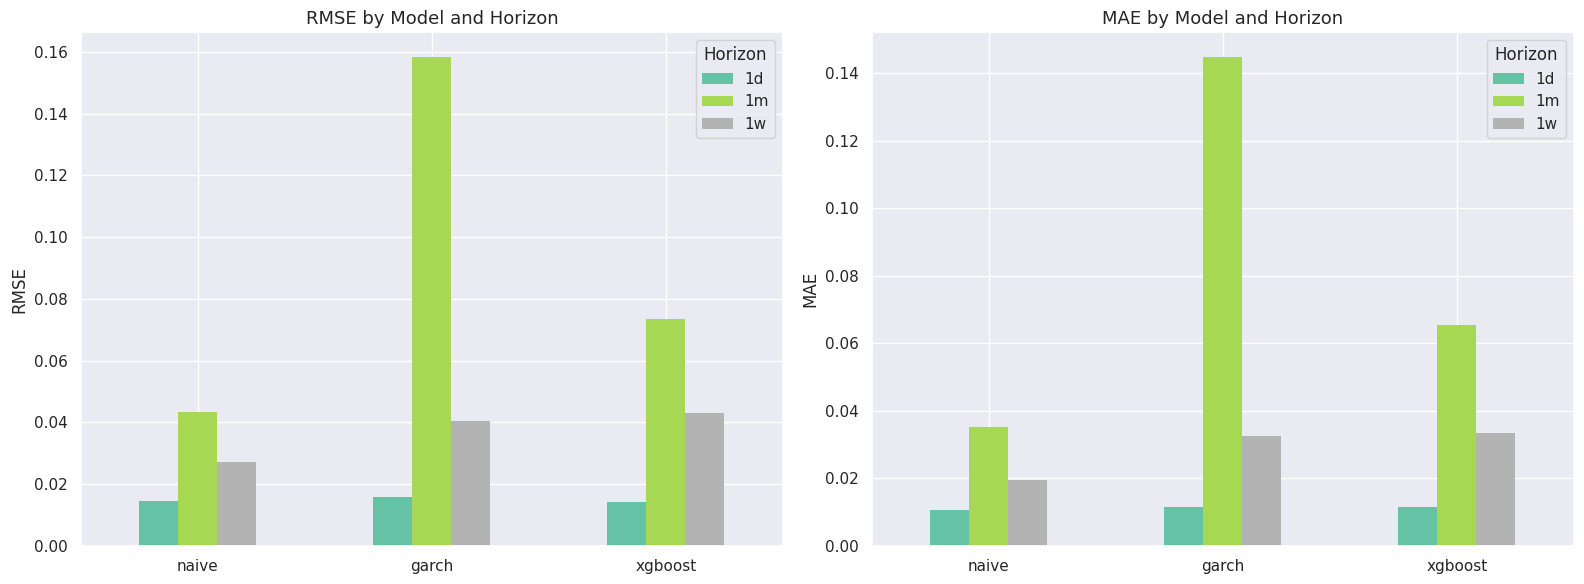

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric in zip(axes, ['rmse', 'mae']):
    pivot = metrics_df.pivot(index='model', columns='horizon', values=metric)
    pivot = pivot.loc[['naive', 'garch', 'xgboost']]  # consistent ordering
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='none')
    ax.set_title(f'{metric.upper()} by Model and Horizon', fontsize=13)
    ax.set_ylabel(metric.upper())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Horizon')

plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/error_comparison_by_model.png', dpi=150, bbox_inches='tight')
plt.show()
# RMSE / MAE comparison

In [ ]:
import datetime
run_summary = f"""# Run Summary

**Date of run       :** {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}
**Dataset frequency :** {FREQ}
**Dataset range     :** {df_model.index.min()} -> {df_model.index.max()}
**Total rows (model):** {len(df_model):,}

## Split Dates
- Train      : {TRAIN_START} -> {VAL_START}
- Validation : {VAL_START} -> {TEST_START}
- Test       : {TEST_START} -> {TEST_END}

## Models Run
- Naive persistence baseline
- GARCH(1,1) with Student-t distribution, refit every {GARCH_REFIT_DAYS} days
- XGBoost (params: {XGB_PARAMS})
- LSTM: {'Run' if RUN_LSTM else 'Skipped (RUN_LSTM=False)'}

## Horizons
- 1-day ahead, 1-week ahead, 1-month ahead

## Features Used
- {len(FEATURE_COLS)} total features
- Categories: return lags, volatility lags, rolling stats, volume/activity, market pressure, price range, time cyclical

## Outputs Saved To
- Clean data   : {DIR_CLEAN}
- Features     : {DIR_FEATURES}
- Models       : {DIR_MODELS}
- Predictions  : {DIR_PREDS}
- Metrics      : {DIR_METRICS}
- Figures      : {DIR_FIGURES}
- Notes        : {DIR_NOTES}

## Metrics Summary
{metrics_df.pivot_table(index='model', columns='horizon', values=['rmse','mae']).round(8).to_string()}
"""

with open(f'{DIR_NOTES}/run_summary.md', 'w') as f:
    f.write(run_summary)

print(run_summary)

# Run Summary

**Date of run       :** 2026-04-18 18:18
**Dataset frequency :** 1h
**Dataset range     :** 2018-01-31 01:00:00 -> 2025-12-11 23:00:00
**Total rows (model):** 68,420

## Split Dates
- Train      : 2018-01-01 -> 2023-01-01
- Validation : 2023-01-01 -> 2024-01-01
- Test       : 2024-01-01 -> 2026-2-1

## Models Run
- Naive persistence baseline
- GARCH(1,1) with Student-t distribution, refit every 30 days
- XGBoost (params: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.08, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1, 'early_stopping_rounds': 30})
- LSTM: Run

## Horizons
- 1-day ahead, 1-week ahead, 1-month ahead

## Features Used
- 57 total features
- Categories: return lags, volatility lags, rolling stats, volume/activity, market pressure, price range, time cyclical

## Outputs Saved To
- Clean data   : outputs/clean
- Features     : outputs/features
- Models       : outputs/models
- Predictions  : outputs/predictions
- Metrics  

Sequence length : 72 hours
Epochs: 50
Batch size: 128
Learning rate: 0.0005
LSTM Horizon: 1d
Train sequences: (42693, 72, 57)
Val sequences: (8519, 72, 57)
Test sequences: (16992, 72, 57)
Epoch 1/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0098 - val_loss: 0.0011
Epoch 2/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0011 - val_loss: 4.0754e-04
Epoch 3/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6.7272e-04 - val_loss: 3.0779e-04
Epoch 4/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5.2159e-04 - val_loss: 2.4591e-04
Epoch 5/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 4.4973e-04 - val_loss: 2.1844e-04
Epoch 6/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4.1052e-04 - val_loss: 2.1249e-04
Epoch 7/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 3.8153e-04 - val_loss: 2.0388e-04
Epoch 8/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 3.5357e-04 - val_loss: 1.9705e-04
Epoch 9/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 3.2

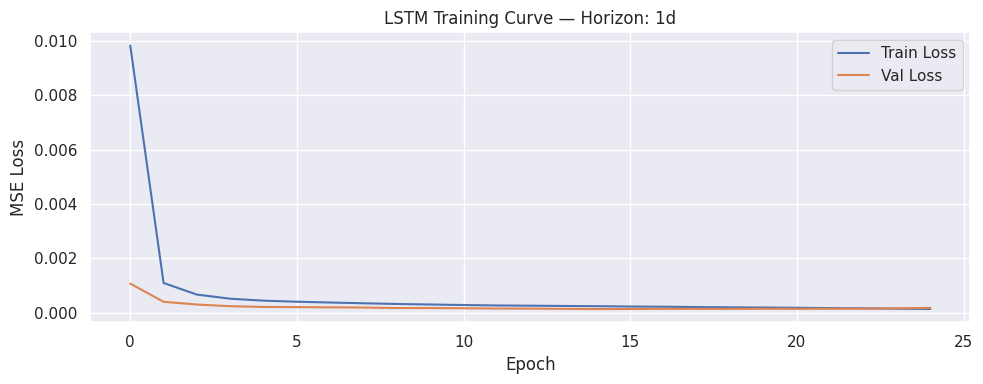

LSTM Horizon: 1w
Train sequences: (42693, 72, 57)
Val sequences: (8519, 72, 57)
Test sequences: (16992, 72, 57)
Epoch 1/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0062 - val_loss: 9.6931e-04
Epoch 2/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0018 - val_loss: 7.1972e-04
Epoch 3/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0014 - val_loss: 5.5631e-04
Epoch 4/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0012 - val_loss: 5.0330e-04
Epoch 5/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0011 - val_loss: 5.0740e-04
Epoch 6/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 9.0236e-04 - val_loss: 5.0147e-04
Epoch 7/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 7.7408e-04 - val_loss: 4.8167e-04
Epoch 8/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 6.1670e-04 - val_loss: 5.6354e-04
Epoch 9/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5.1269e-04 - val_loss: 5.3547e-04
Epoch 10/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

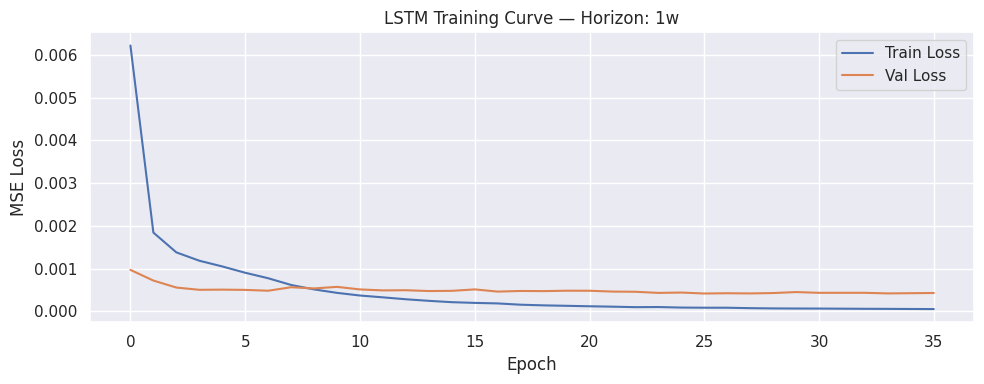

LSTM Horizon: 1m
Train sequences: (42693, 72, 57)
Val sequences: (8519, 72, 57)
Test sequences: (16992, 72, 57)
Epoch 1/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0097 - val_loss: 0.0062
Epoch 2/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0041 - val_loss: 0.0058
Epoch 3/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0028 - val_loss: 0.0094
Epoch 4/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0017 - val_loss: 0.0114
Epoch 5/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0012 - val_loss: 0.0115
Epoch 6/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 9.6622e-04 - val_loss: 0.0127
Epoch 7/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 7.9574e-04 - val_loss: 0.0121
Epoch 8/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 6.7813e-04 - val_loss: 0.0123
Epoch 9/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6.2102e-04 - val_loss: 0.0133
Epoch 10/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5.1986e-04 - val_loss: 0.01

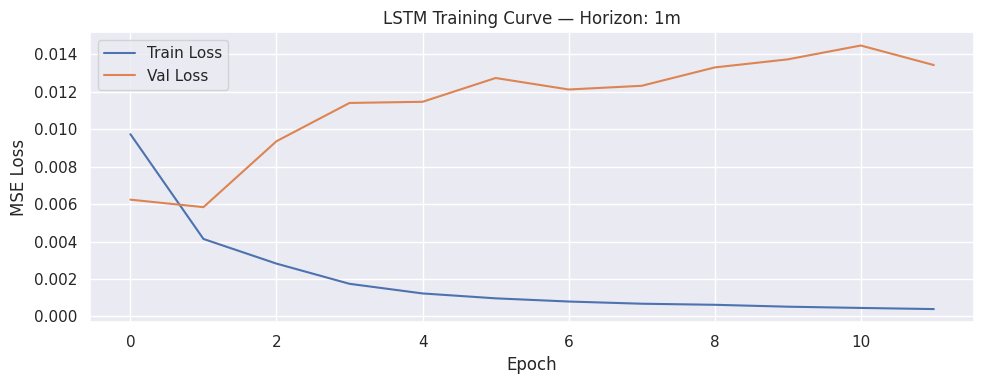

              mae                          rmse                    
horizon        1d        1m        1w        1d        1m        1w
model                                                              
garch    0.011525  0.144791  0.032508  0.015800  0.158423  0.040536
lstm     0.015229  0.074715  0.030994  0.030577  0.085120  0.039169
naive    0.010737  0.035086  0.019515  0.014478  0.043410  0.026994
xgboost  0.011381  0.065245  0.033324  0.014194  0.073376  0.043175


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(RANDOM_SEED)
print(f'Sequence length : {LSTM_SEQ_LEN} hours')
print(f'Epochs: {LSTM_EPOCHS}')
print(f'Batch size: {LSTM_BATCH}')
print(f'Learning rate: {LSTM_LR}')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

def make_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X_arr)):
        Xs.append(X_arr[i - seq_len:i])
        ys.append(y_arr[i])
    return np.array(Xs), np.array(ys)
# Convert the 2D feature array into 3D sequences

lstm_models = {}
lstm_preds  = {}
lstm_histories = {}
for h in HORIZONS:
    print(f'LSTM Horizon: {h}')
    y_tr_arr = y_train[h].values
    y_vl_arr = y_val[h].values
    y_te_arr = y_test[h].values
    X_tr_seq, y_tr_seq = make_sequences(X_train_scaled, y_tr_arr, LSTM_SEQ_LEN)
    X_vl_seq, y_vl_seq = make_sequences(X_val_scaled,   y_vl_arr, LSTM_SEQ_LEN)
    X_te_seq, y_te_seq = make_sequences(X_test_scaled,  y_te_arr, LSTM_SEQ_LEN)
    print(f'Train sequences: {X_tr_seq.shape}')
    print(f'Val sequences: {X_vl_seq.shape}')
    print(f'Test sequences: {X_te_seq.shape}')
    model = keras.Sequential([
        layers.Input(shape=(LSTM_SEQ_LEN, X_tr_seq.shape[2])),
        layers.LSTM(32, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(16, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)])
        # Two-layer LSTM

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LSTM_LR), loss='mse')
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1)
    history = model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_vl_seq, y_vl_seq),
        epochs=LSTM_EPOCHS,
        batch_size=LSTM_BATCH,
        callbacks=[early_stop],
        verbose=1)
    lstm_histories[h] = history.history
    preds = model.predict(X_te_seq).flatten()
    # Predict on the test set

    test_ts_aligned = test_df.index[LSTM_SEQ_LEN:]
    actual_aligned  = y_te_seq
    lstm_preds[h] = pd.DataFrame({
        'timestamp' : test_ts_aligned[:len(preds)],
        'actual'    : actual_aligned[:len(preds)],
        'predicted' : preds,
        'model'     : 'lstm',
        'horizon'   : h
    })
    # Align predictions with test timestamps

    lstm_preds[h].to_csv(f'{DIR_PREDS}/lstm_{h}_predictions.csv', index=False)
    model.save(f'{DIR_MODELS}/lstm_{h}.keras')
    lstm_models[h] = model
    m = evaluate_predictions(
        lstm_preds[h]['actual'].values,
        lstm_preds[h]['predicted'].values,
        'lstm', h
    )
    print(f'LSTM {h} -> RMSE: {m["rmse"]:.6f}  MAE: {m["mae"]:.6f}')


    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history['loss'], label='Train Loss')
    ax.plot(history.history['val_loss'], label='Val Loss')
    ax.set_title(f'LSTM Training Curve — Horizon: {h}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{DIR_FIGURES}/lstm_training_curve_{h}.png', dpi=150, bbox_inches='tight')
    plt.show()
    # Training curve

lstm_metrics = []
for h in HORIZONS:
    df_l = lstm_preds[h]
    m = evaluate_predictions(df_l['actual'].values, df_l['predicted'].values, 'lstm', h)
    lstm_metrics.append(m)
metrics_all = pd.concat([metrics_df, pd.DataFrame(lstm_metrics)], ignore_index=True)
metrics_all.to_csv(f'{DIR_METRICS}/metrics_summary_with_lstm.csv', index=False)
pivot_all = metrics_all.pivot_table(index='model', columns='horizon', values=['rmse','mae'])
print(pivot_all.round(6))

LSTM predictions available: True
Generating all summary charts...

Chart 1: EDA — Price, Returns, Rolling Volatility


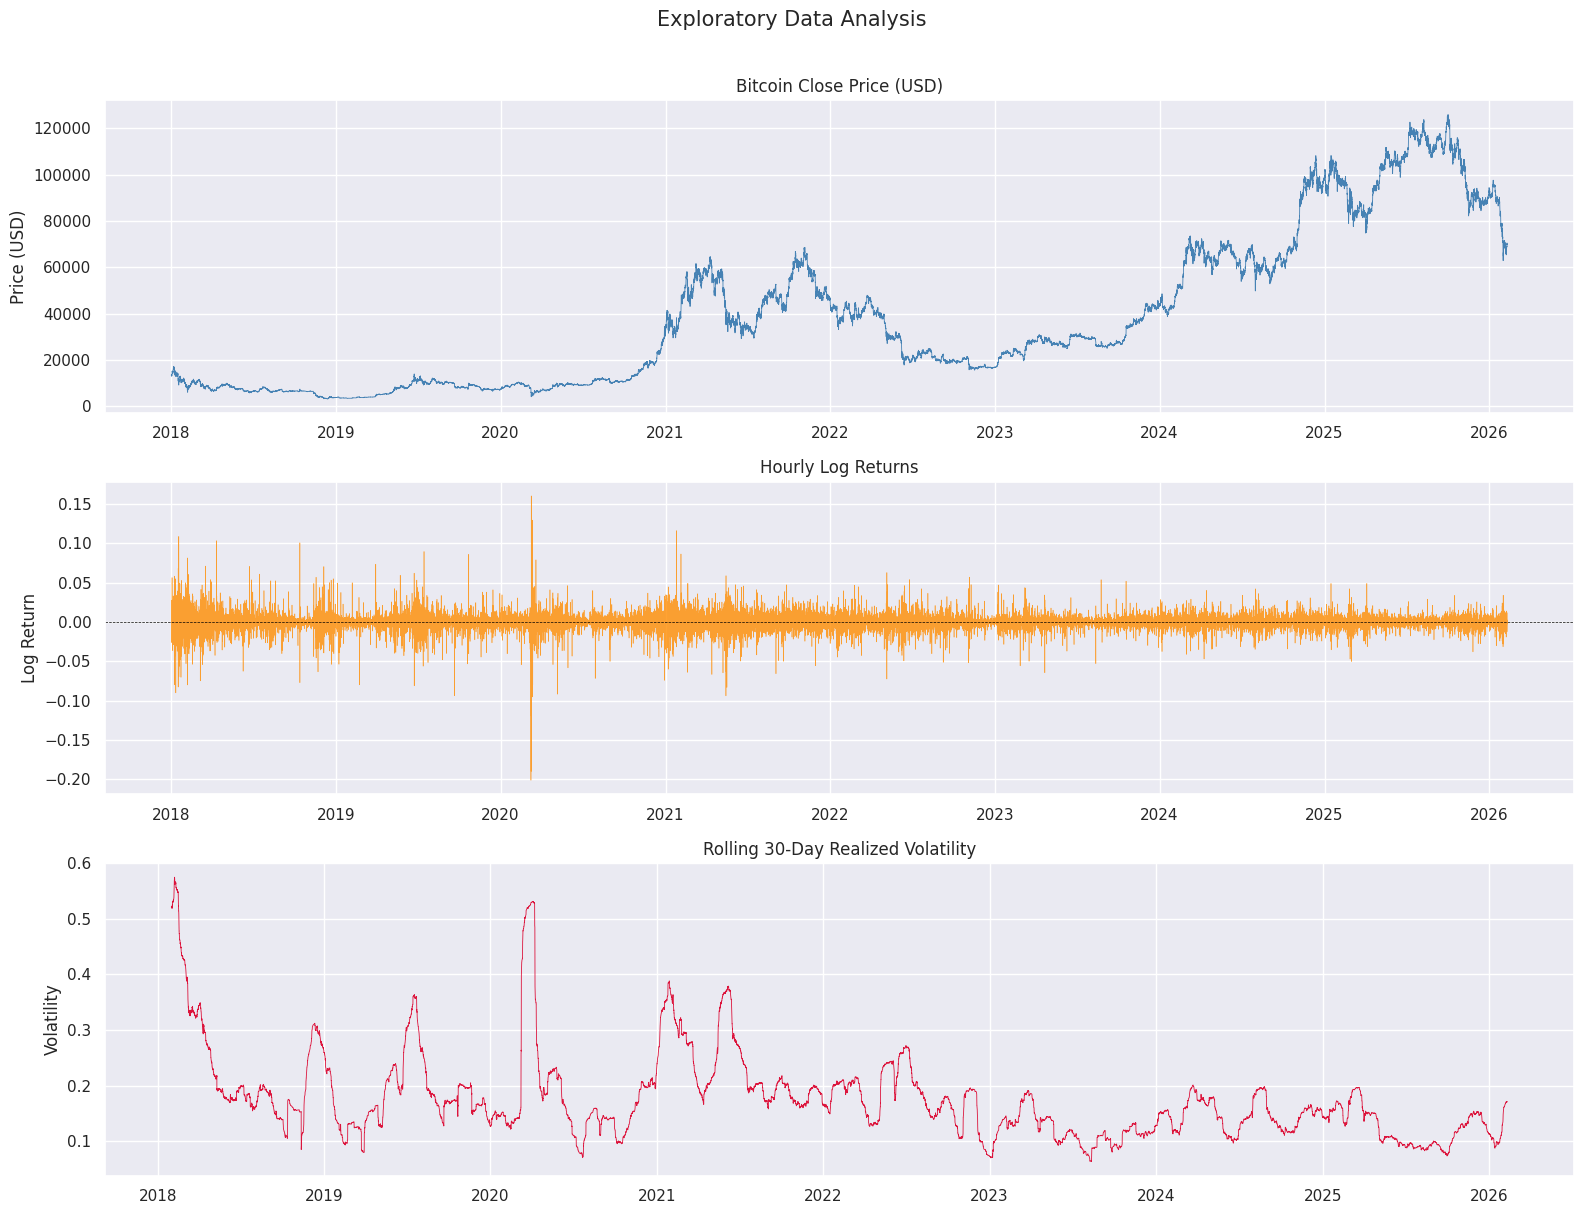

Chart 2: Return Distribution


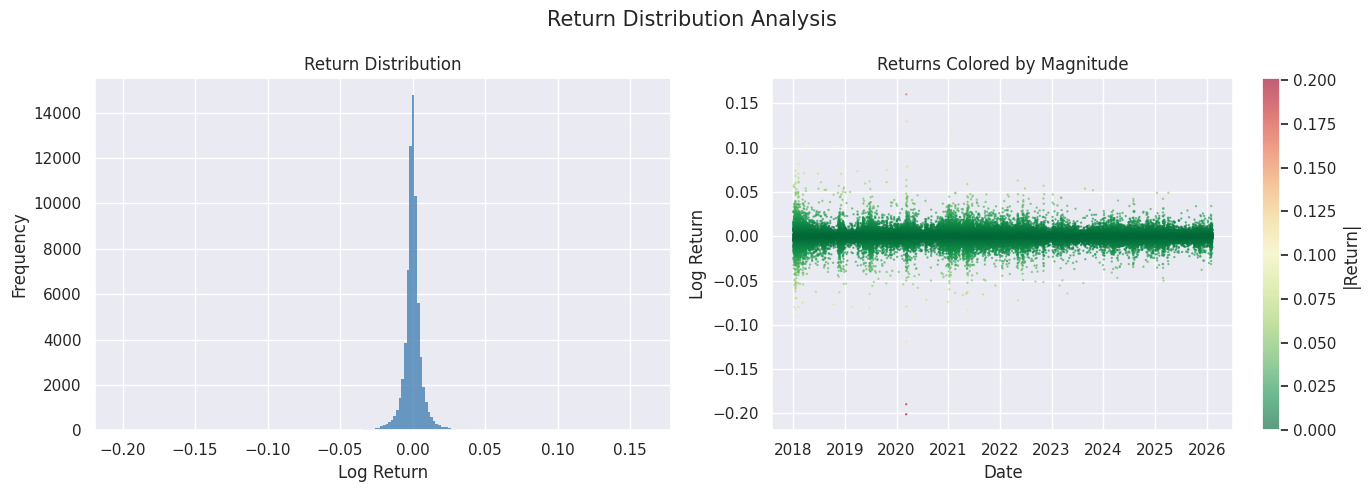

Chart 3: Volume and Buy Pressure


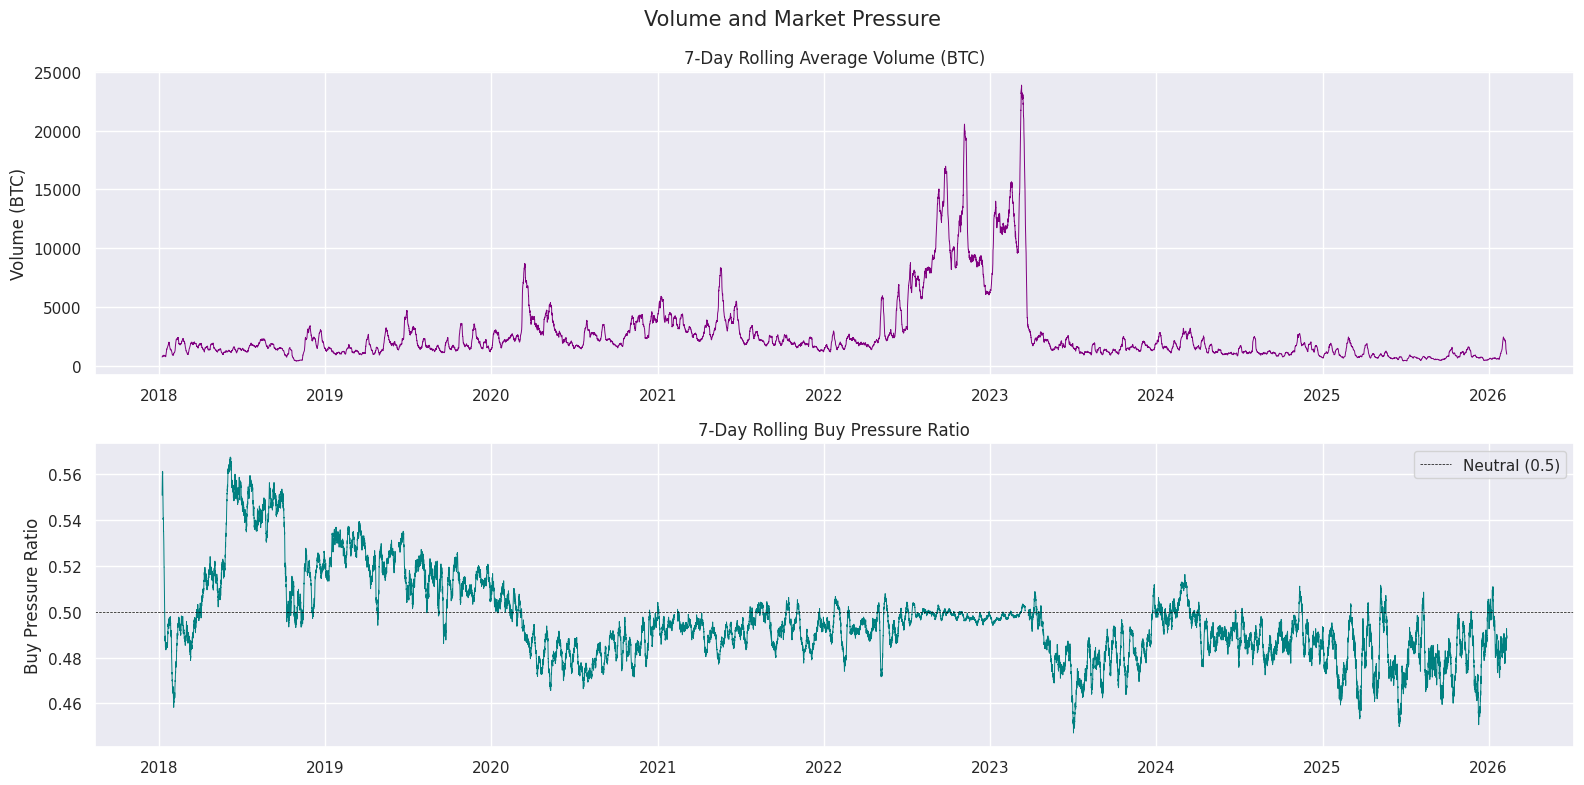

Chart 4: Realized Volatility Targets


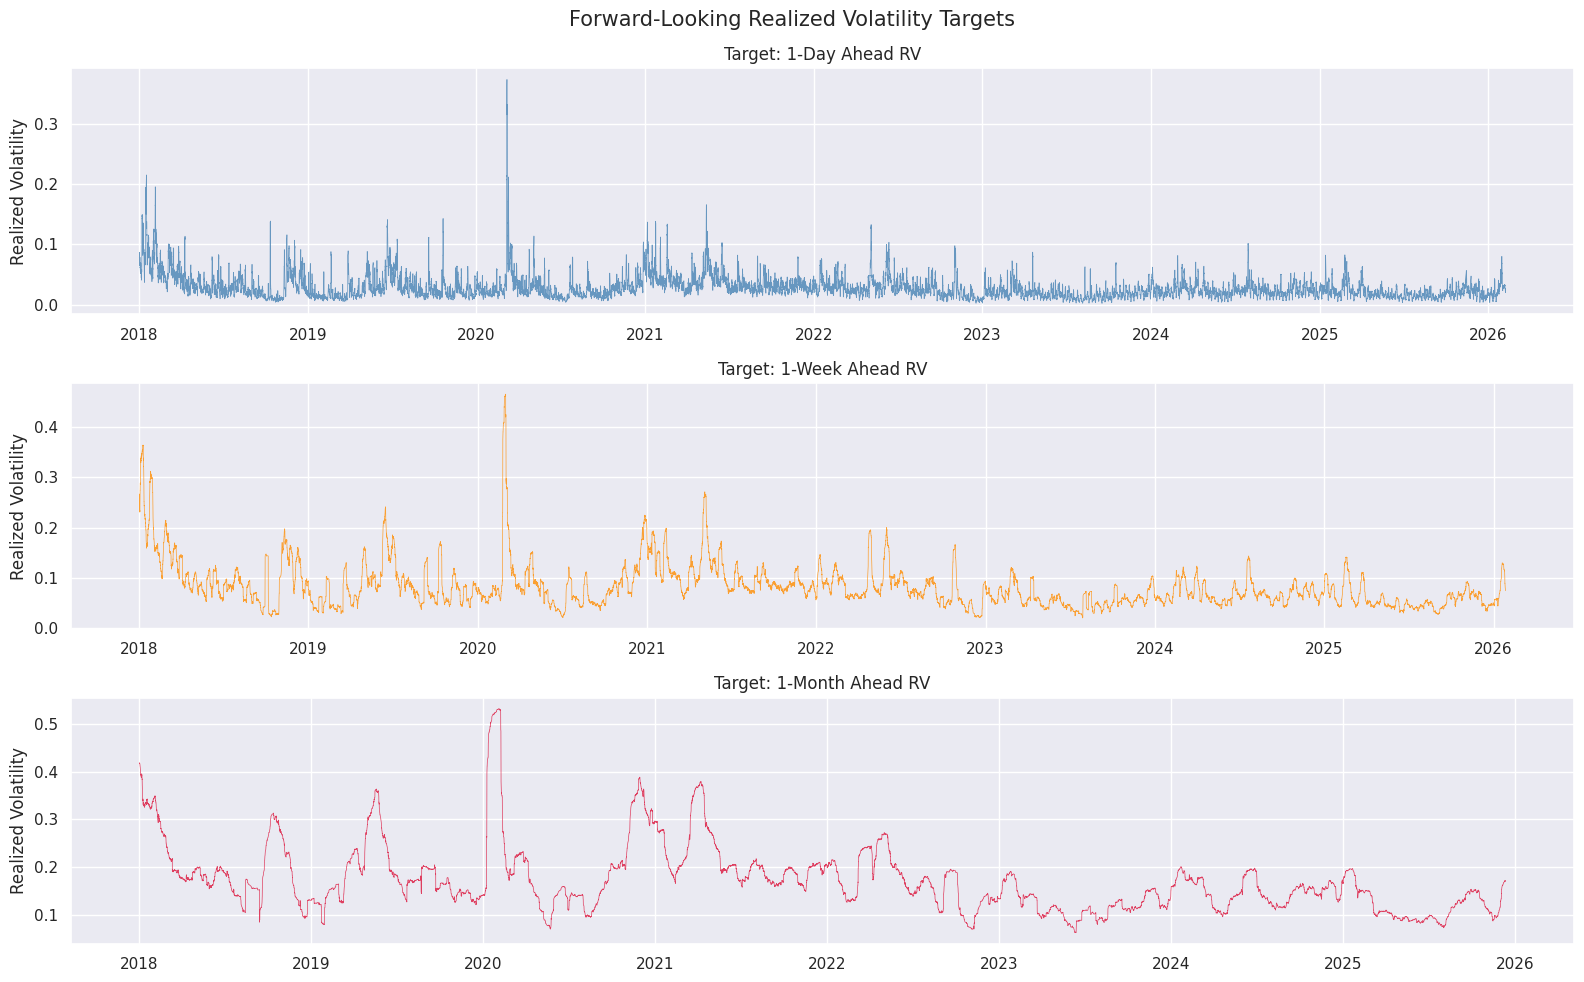

Chart 5: XGBoost Feature Importance


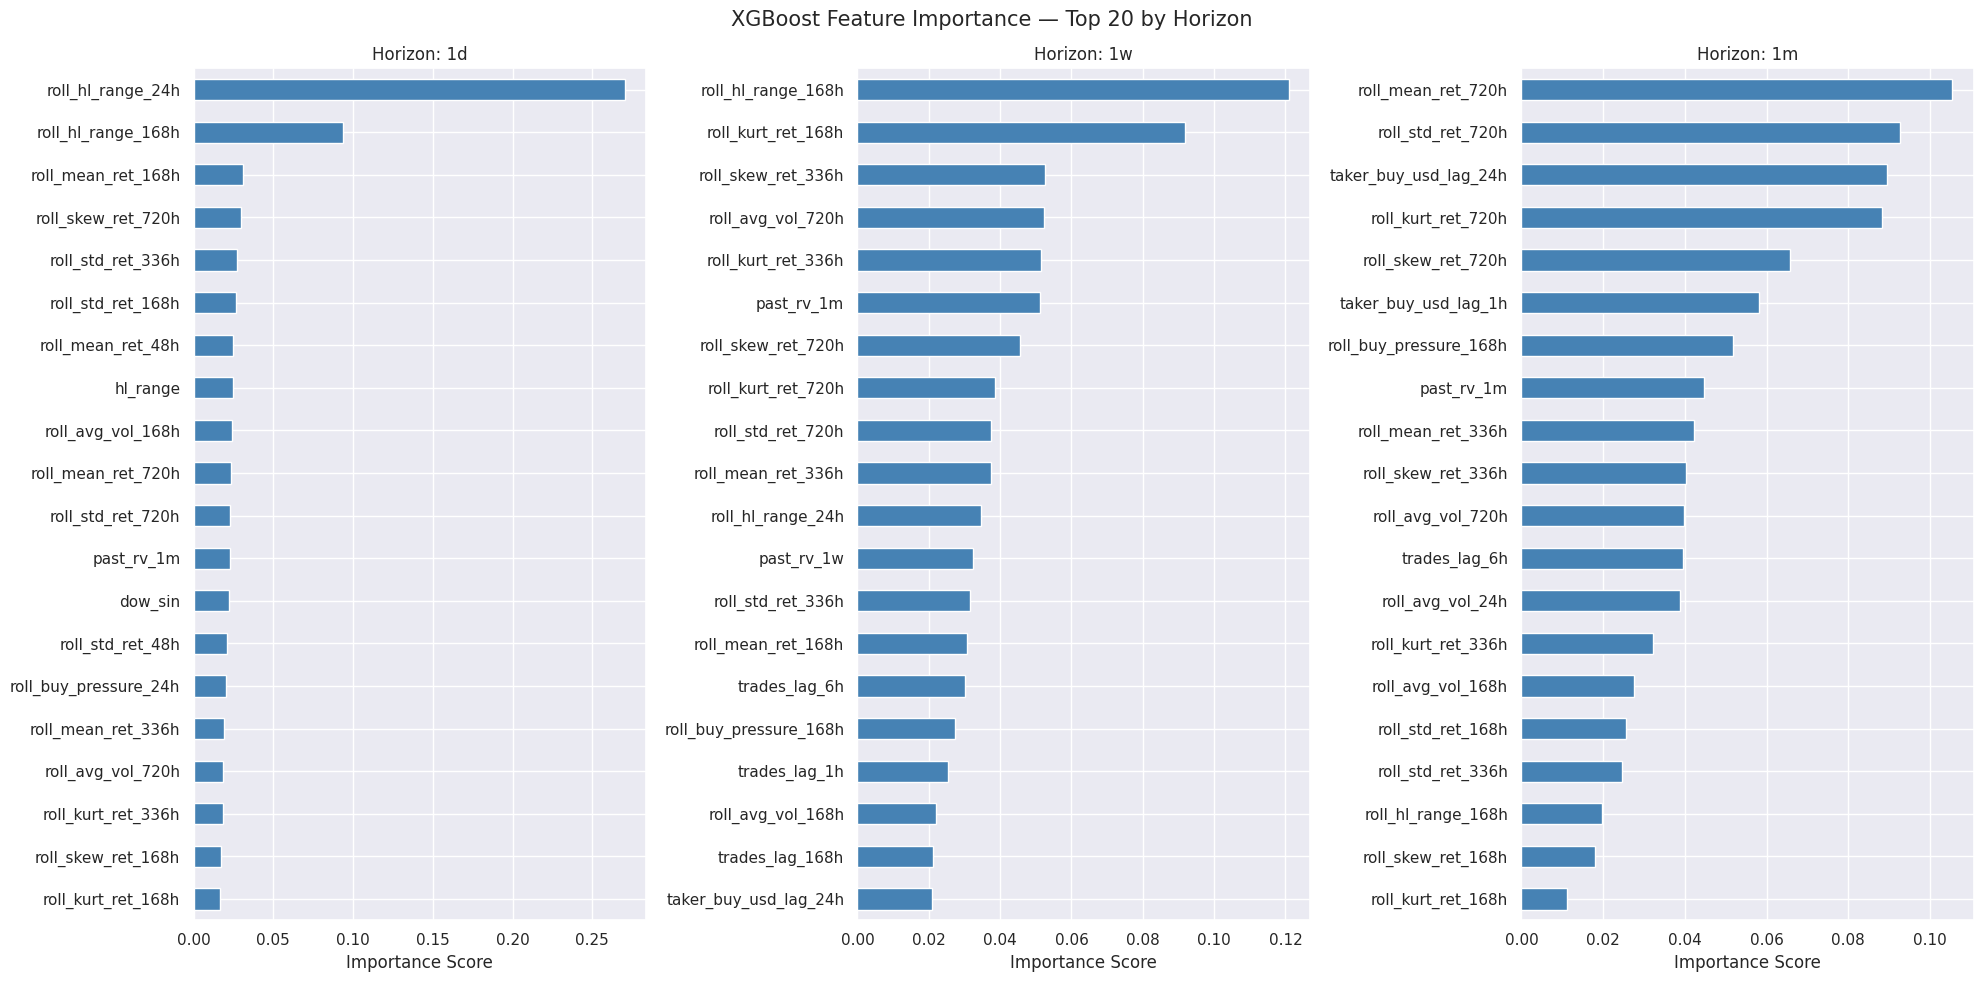

Chart 6: Actual vs Predicted — all models per horizon


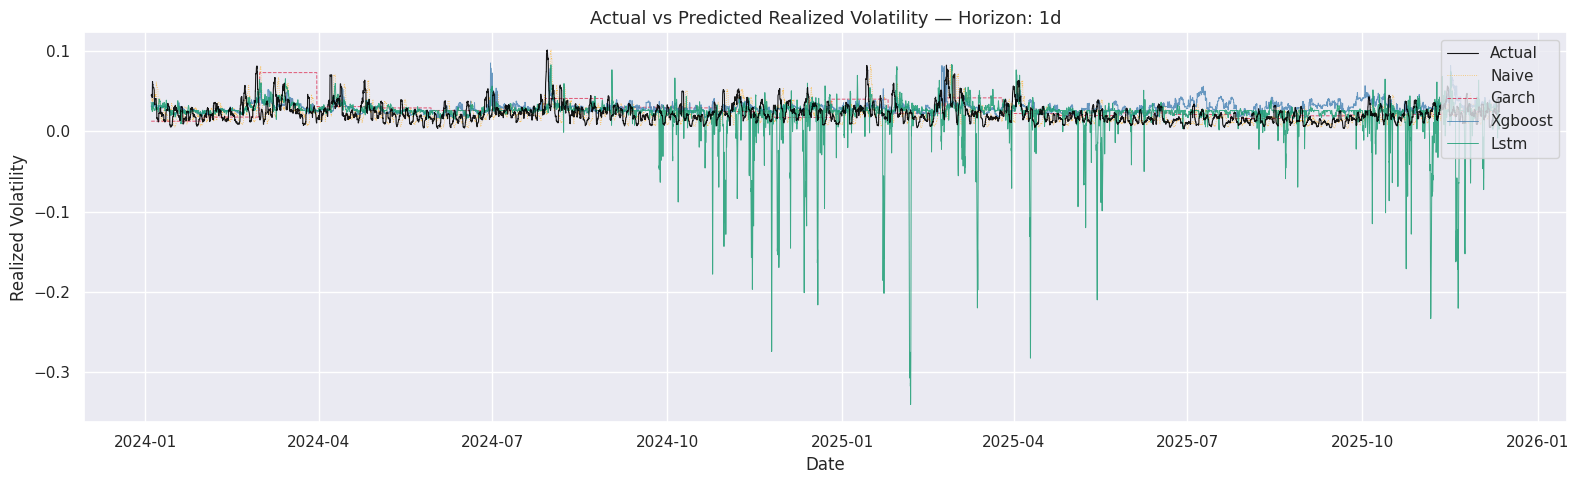

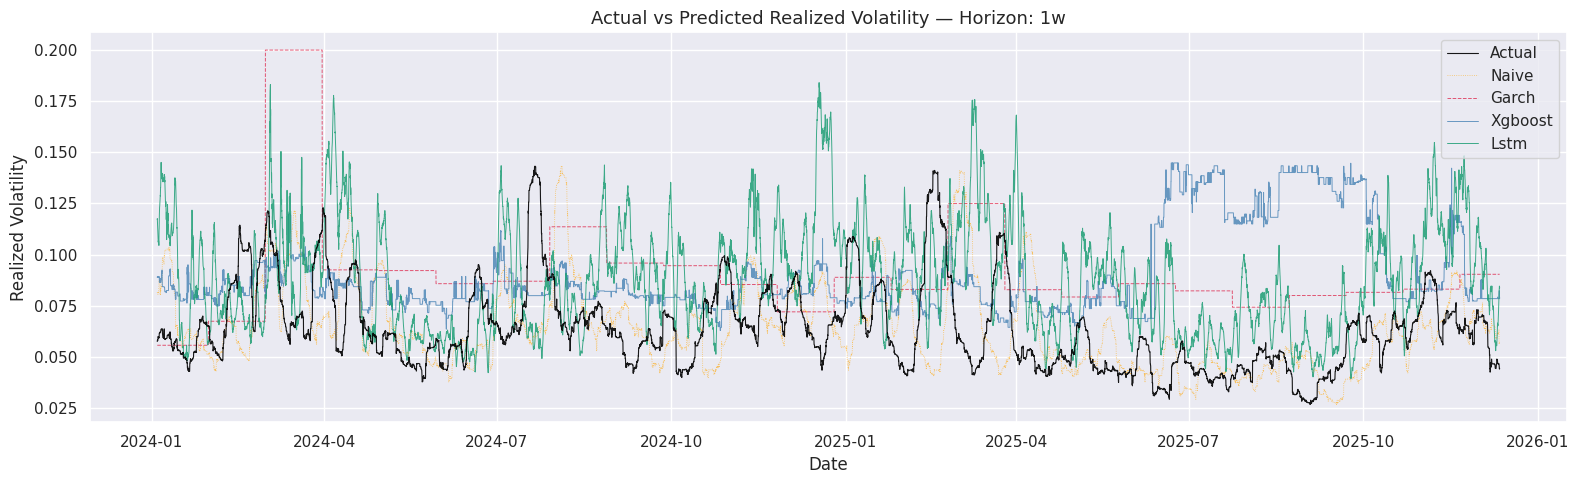

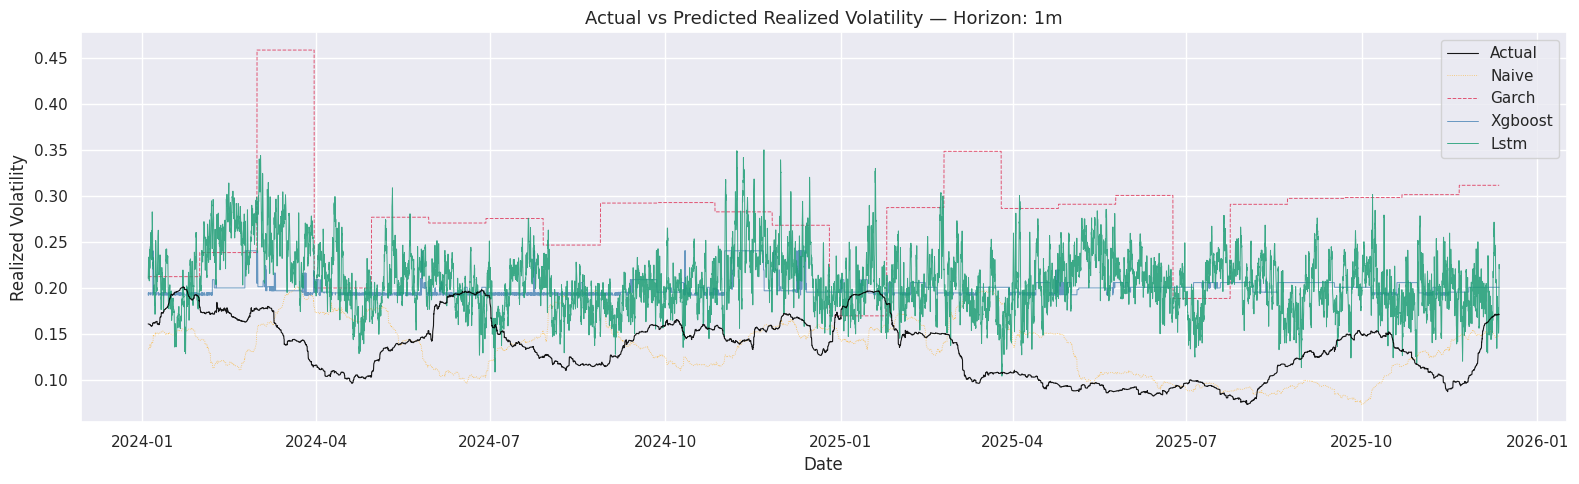

Chart 7: Residual Analysis


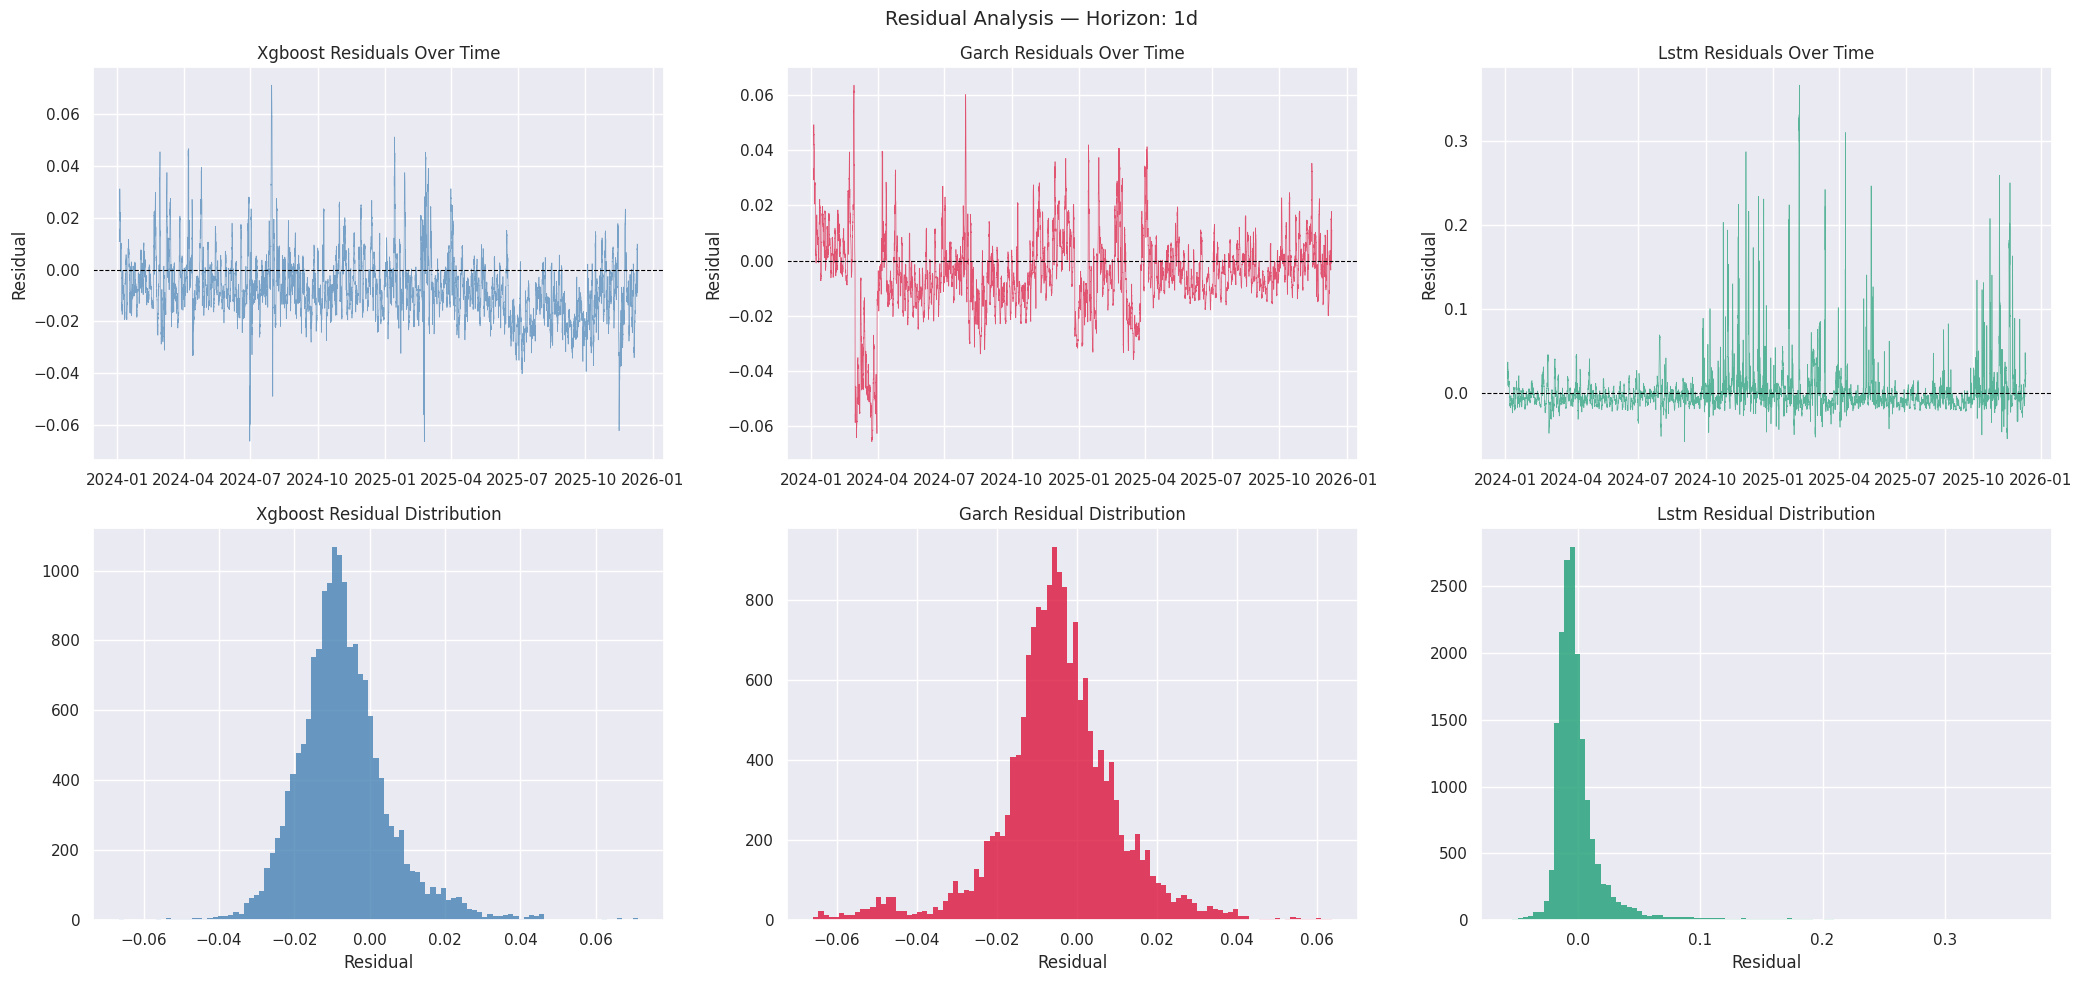

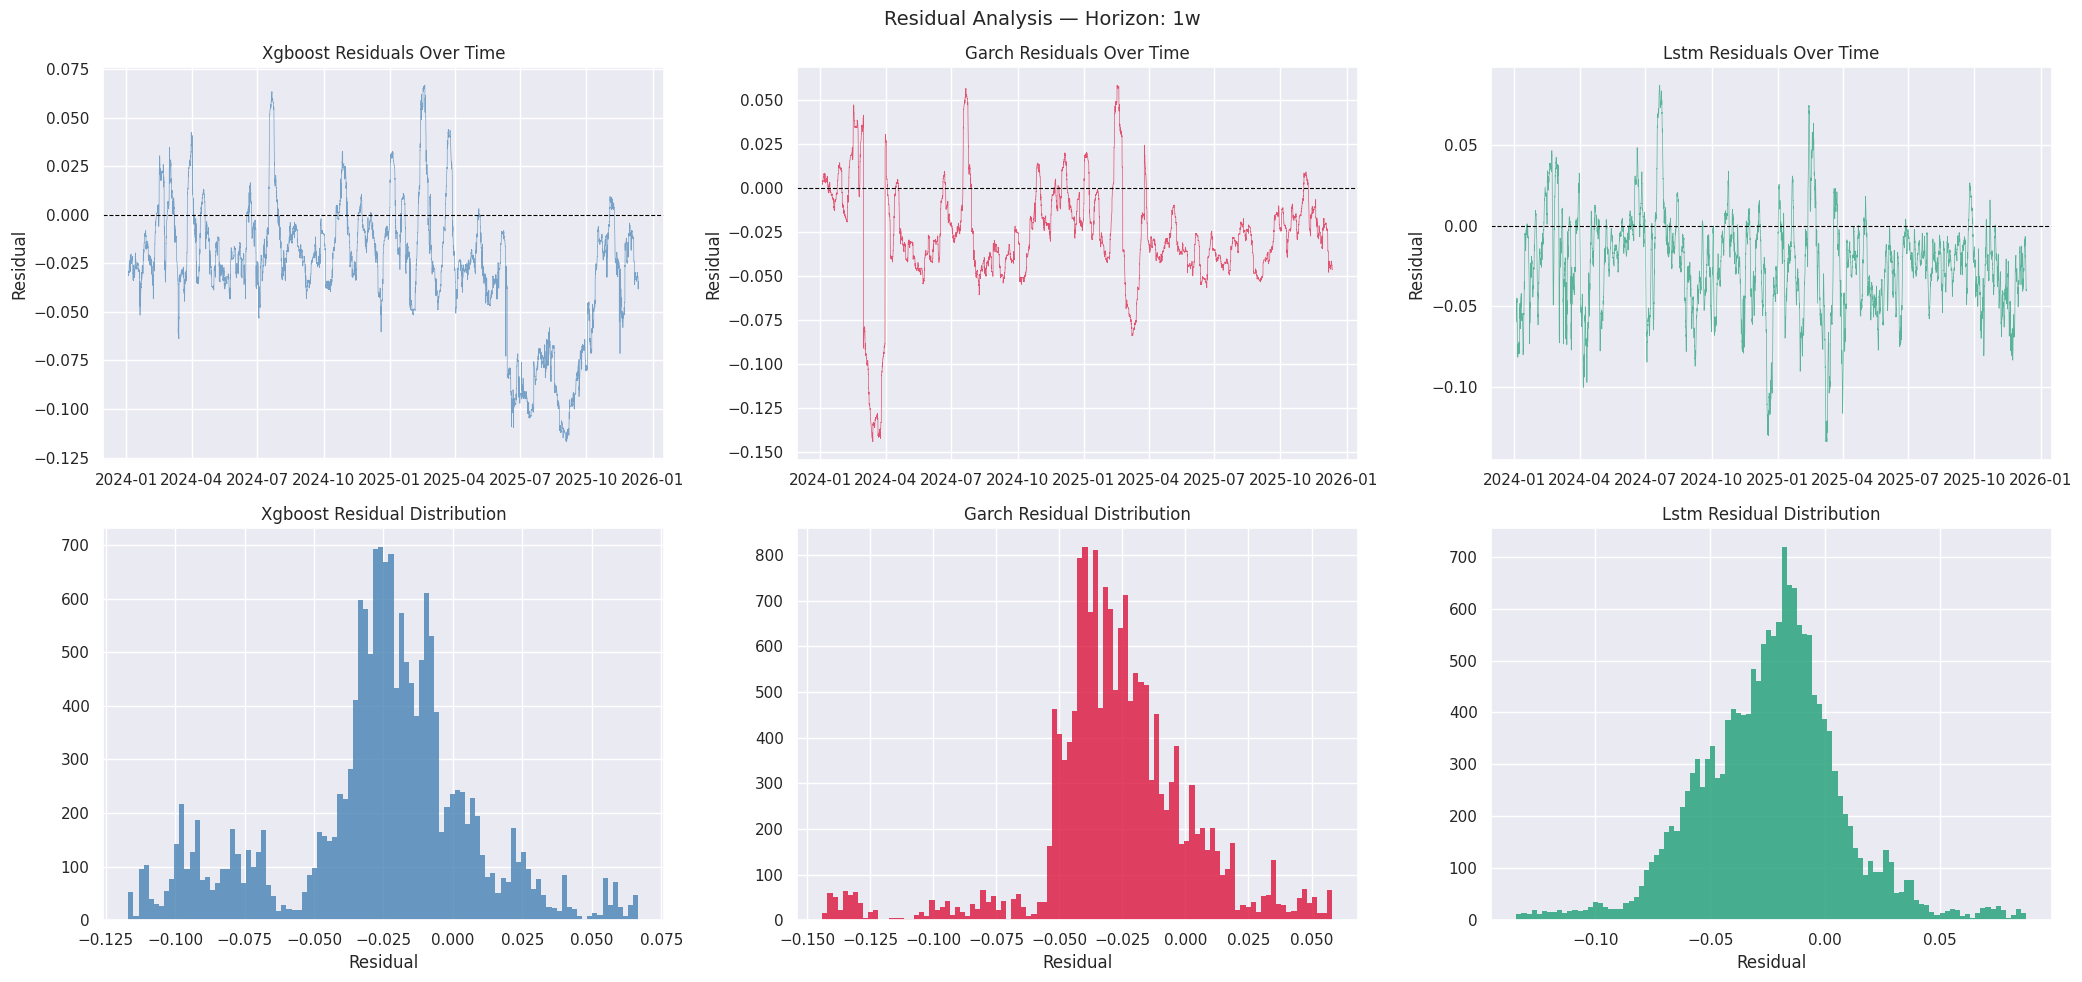

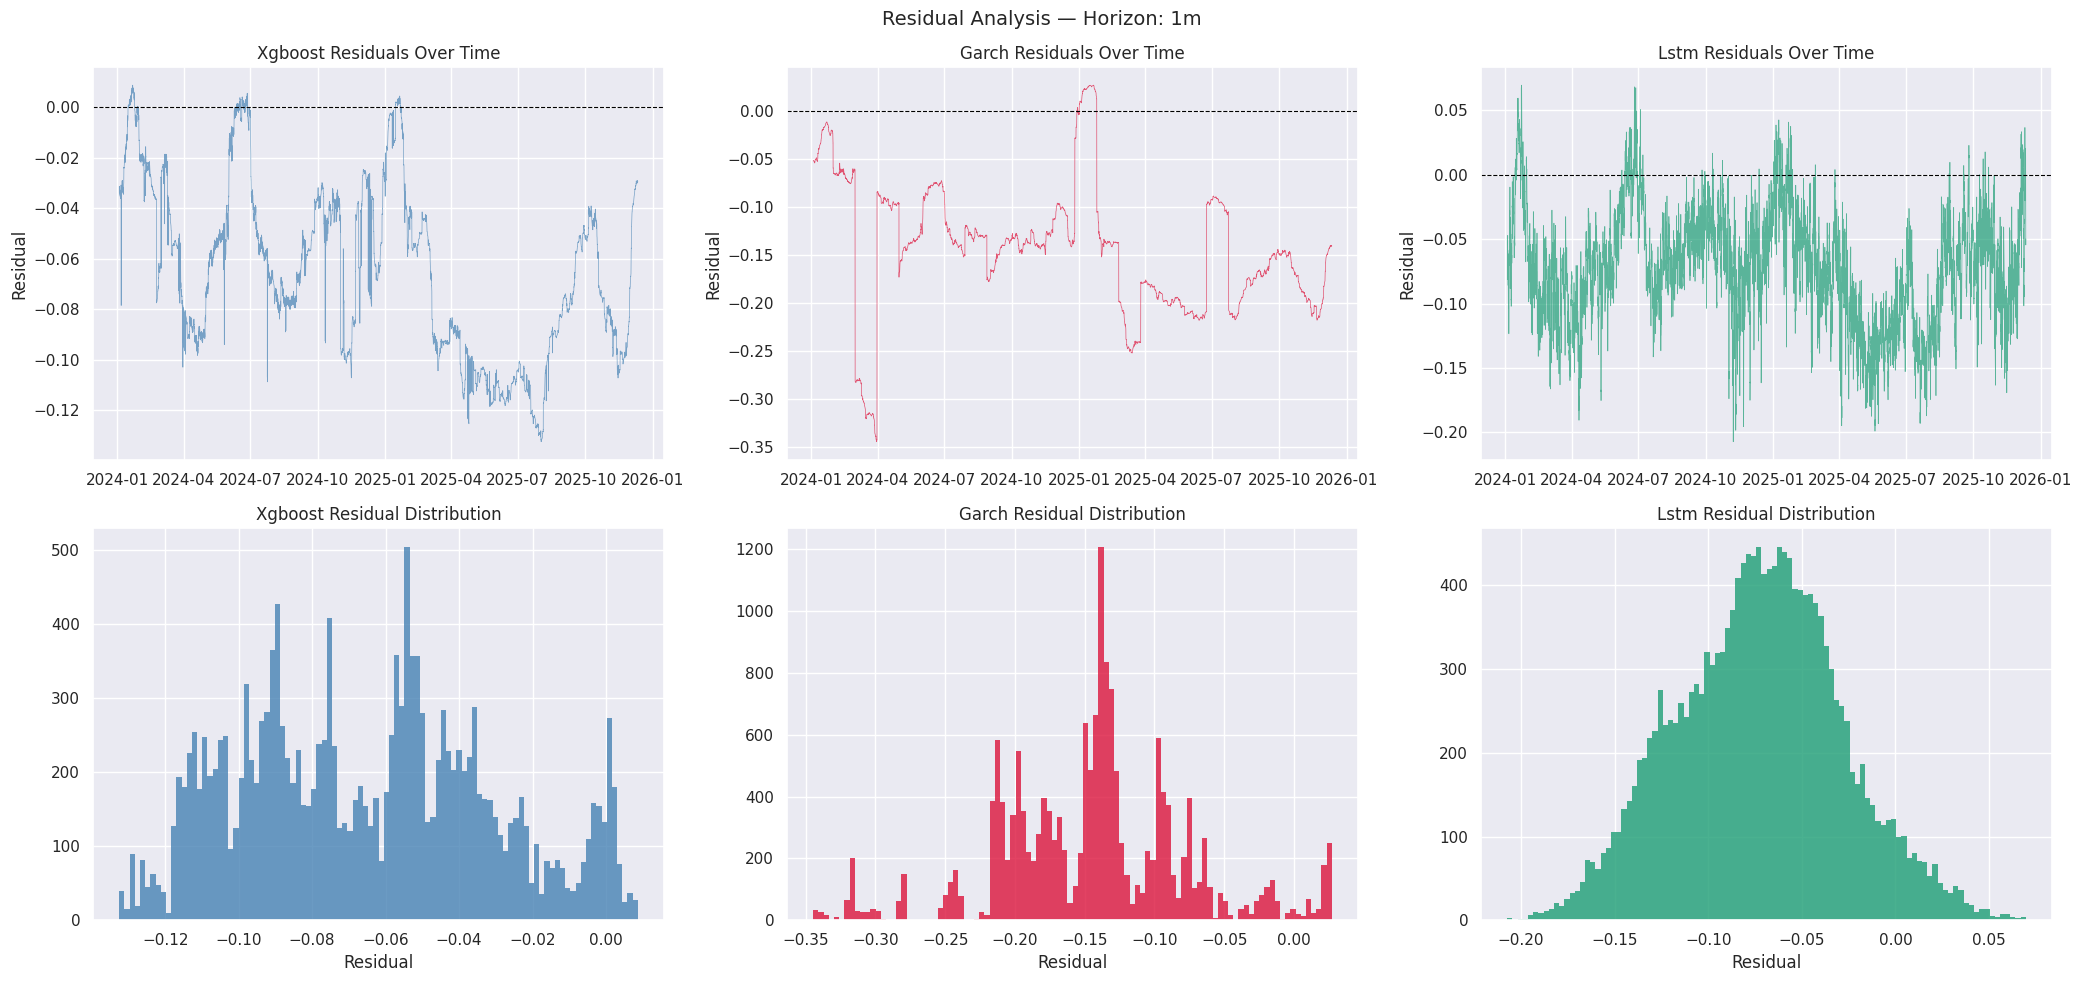

Chart 8: Full Metrics Comparison including LSTM

Full metrics table (all models):
              mae                          rmse                    
horizon        1d        1m        1w        1d        1m        1w
model                                                              
garch    0.011525  0.144791  0.032508  0.015800  0.158423  0.040536
lstm     0.015229  0.074715  0.030994  0.030577  0.085120  0.039169
naive    0.010737  0.035086  0.019515  0.014478  0.043410  0.026994
xgboost  0.011381  0.065245  0.033324  0.014194  0.073376  0.043175


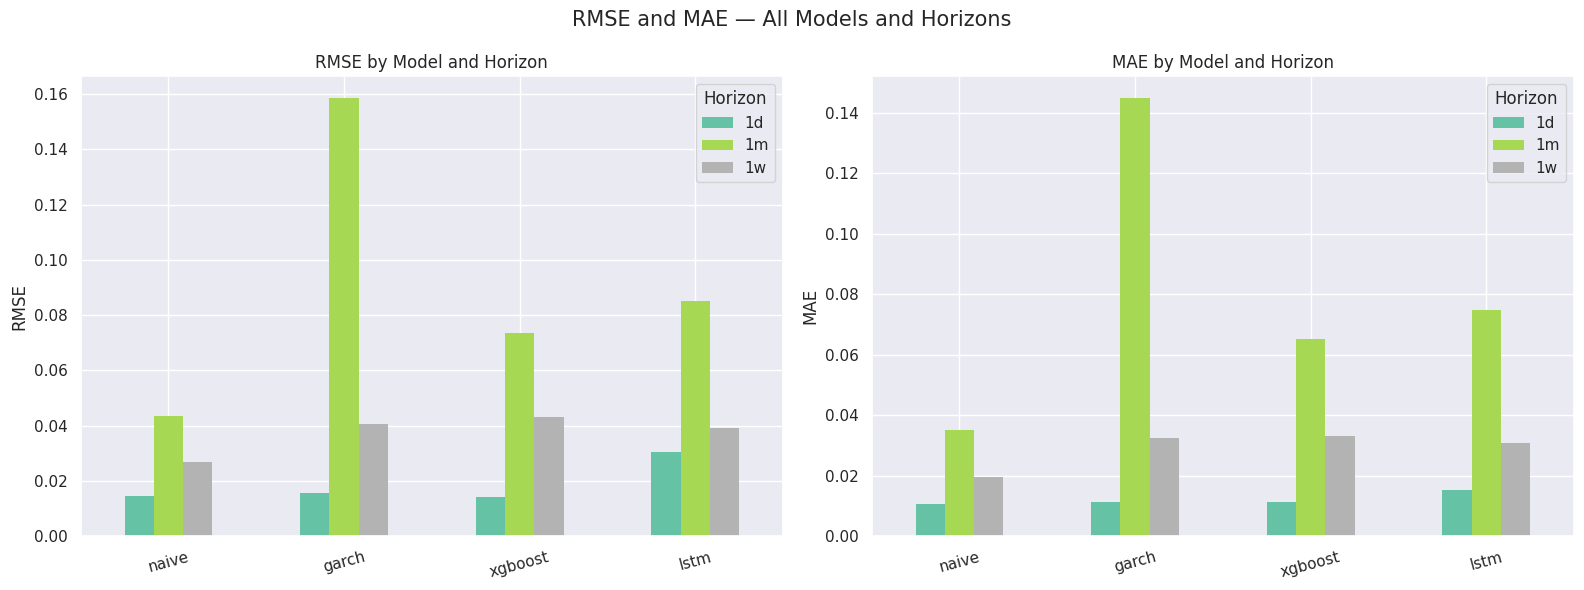

Chart 9: LSTM vs XGBoost vs GARCH — Direct Comparison per Horizon


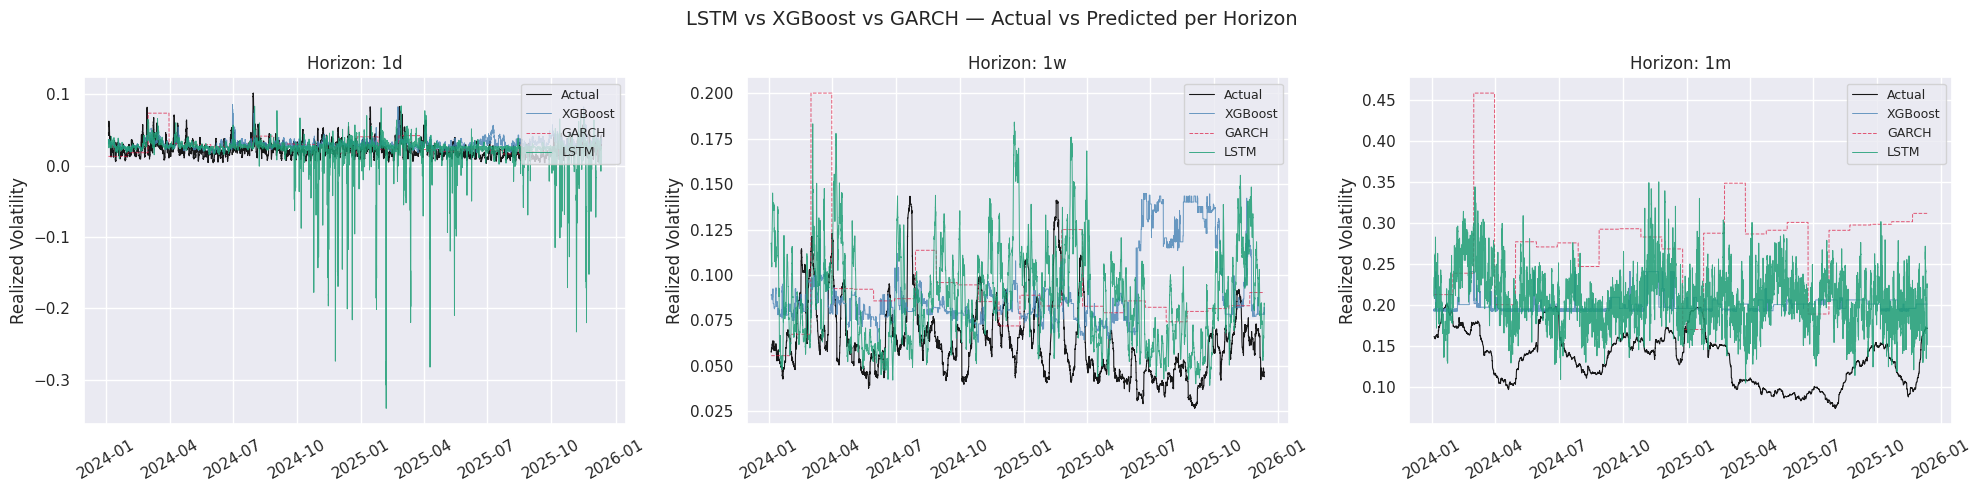

Chart 10: LSTM vs XGBoost Residuals — Side by Side per Horizon


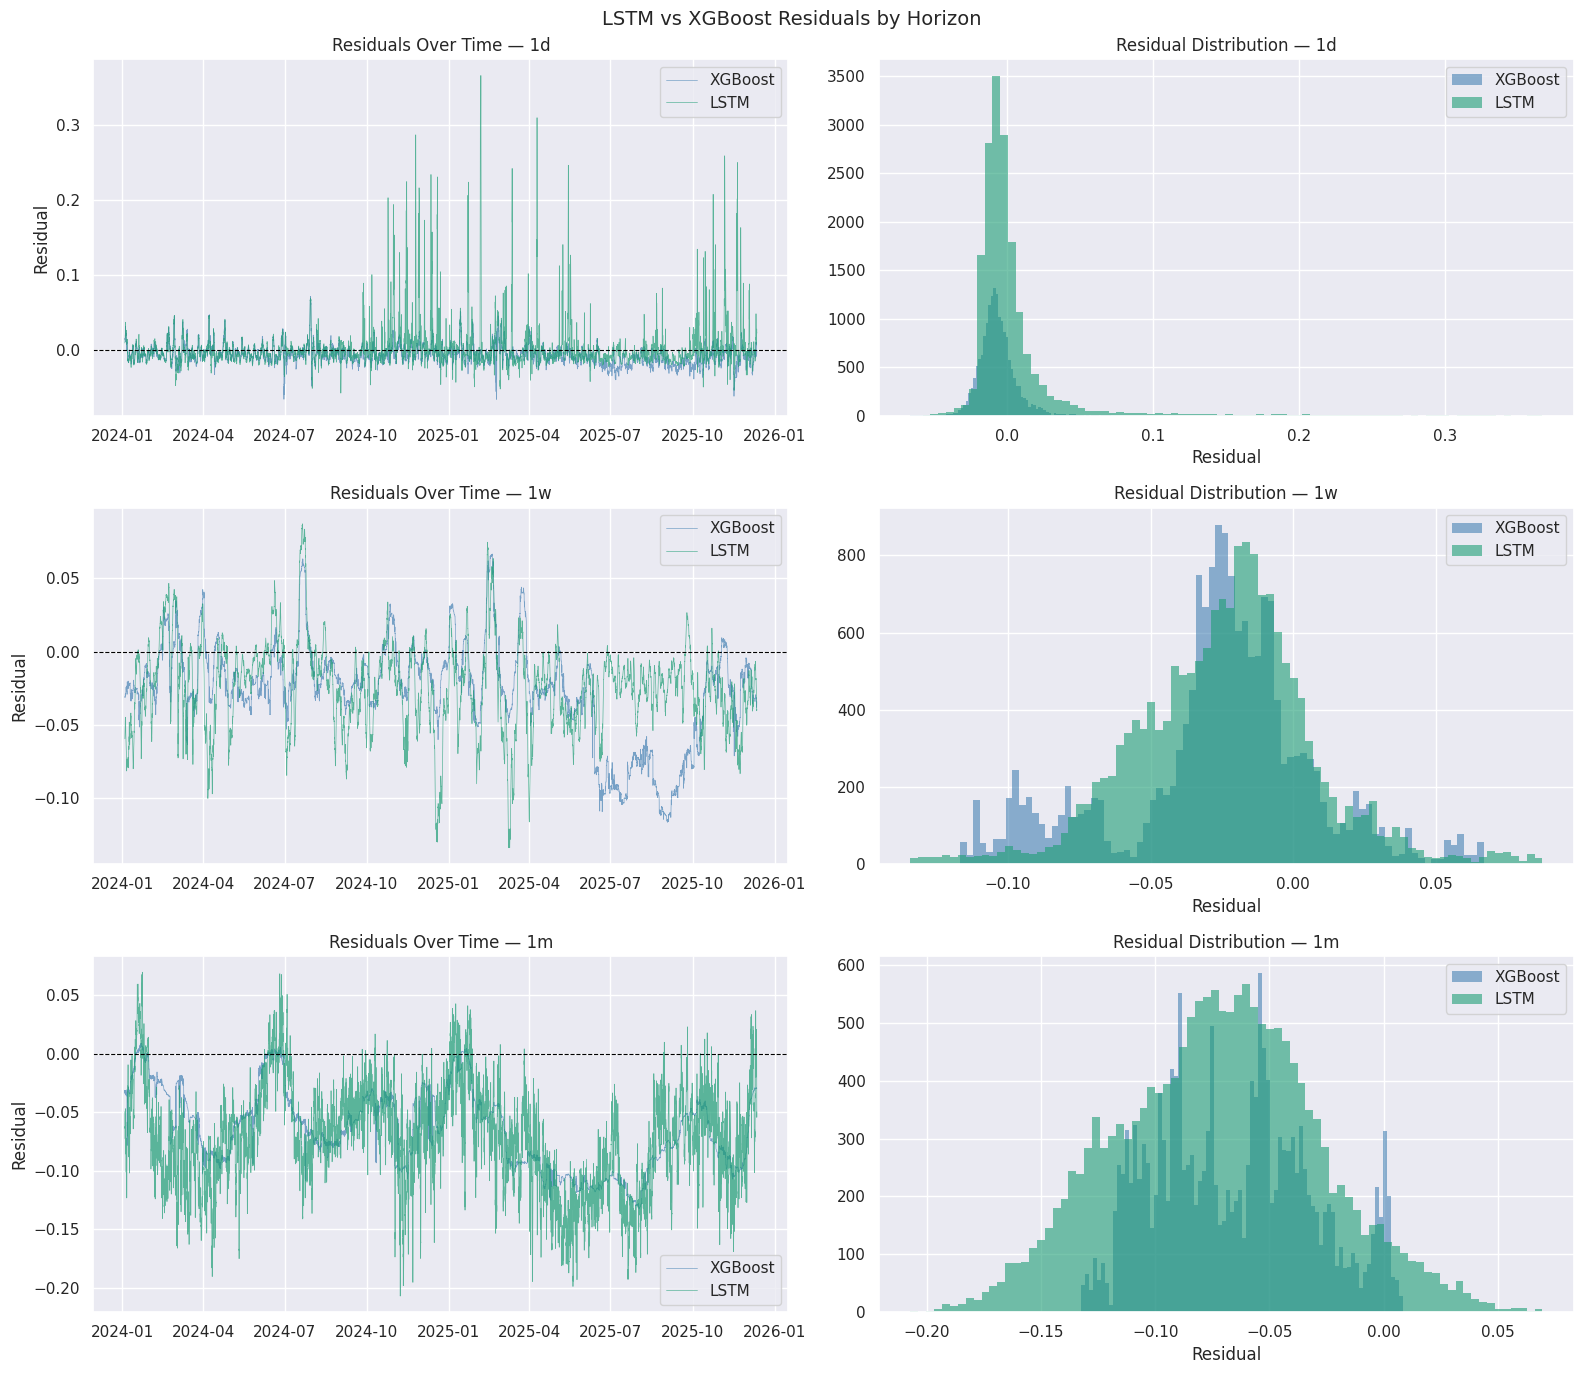

Chart 11: Mincer-Zarnowitz Summary

Mincer-Zarnowitz results (perfect forecast: alpha=0, beta=1):
  model horizon  mz_alpha   mz_beta    mz_r2
  naive      1d  0.017538  0.229606 0.052626
  garch      1d  0.017564  0.189995 0.039702
xgboost      1d  0.013264  0.318898 0.033814
  naive      1w  0.052137  0.179817 0.033095
  garch      1w  0.048510  0.167268 0.045011
xgboost      1w  0.096727 -0.365907 0.125896
  naive      1m  0.122904  0.088579 0.007515
  garch      1m  0.151794 -0.060477 0.010837
xgboost      1m  0.131273  0.018444 0.000033
   lstm      1d  0.022499  0.009378 0.000526
   lstm      1w  0.051552  0.138640 0.031065
   lstm      1m  0.113147  0.104617 0.011890


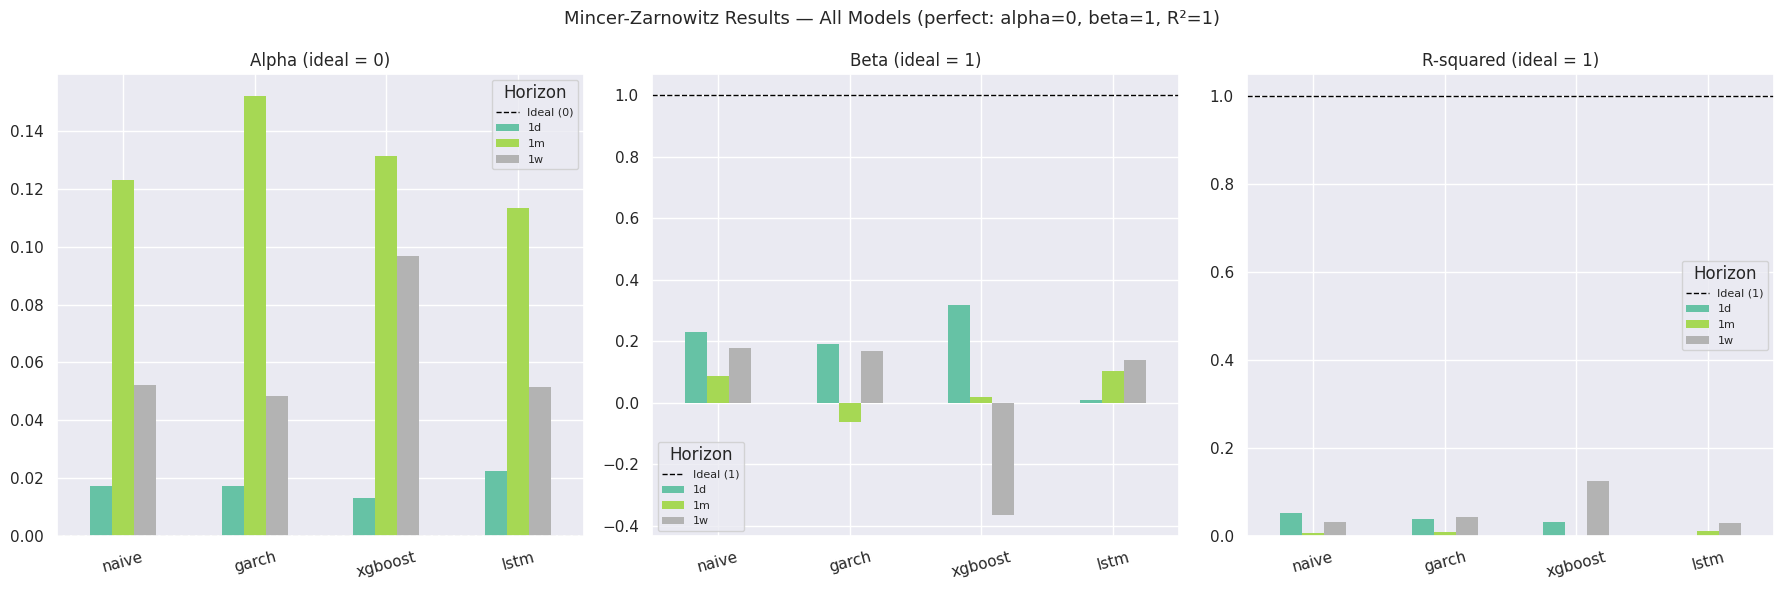

Chart 12: Diebold-Mariano Extended including LSTM

Full Diebold-Mariano results (p < 0.05 = statistically significant):
horizon      comparison   dm_stat  p_value
     1d    XGB vs GARCH  -11.4757   0.0000
     1d    XGB vs Naive   -2.6007   0.0093
     1w    XGB vs GARCH    7.0542   0.0000
     1w    XGB vs Naive   45.7341   0.0000
     1m    XGB vs GARCH -132.0464   0.0000
     1m    XGB vs Naive   88.9126   0.0000
     1d   LSTM vs GARCH   15.6884   0.0000
     1d   LSTM vs Naive   16.6255   0.0000
     1d LSTM vs XGBoost   16.8049   0.0000
     1w   LSTM vs GARCH   -4.1355   0.0000
     1w   LSTM vs Naive   43.6738   0.0000
     1w LSTM vs XGBoost  -11.5332   0.0000
     1m   LSTM vs GARCH -121.2739   0.0000
     1m   LSTM vs Naive   91.9091   0.0000
     1m LSTM vs XGBoost   44.5688   0.0000


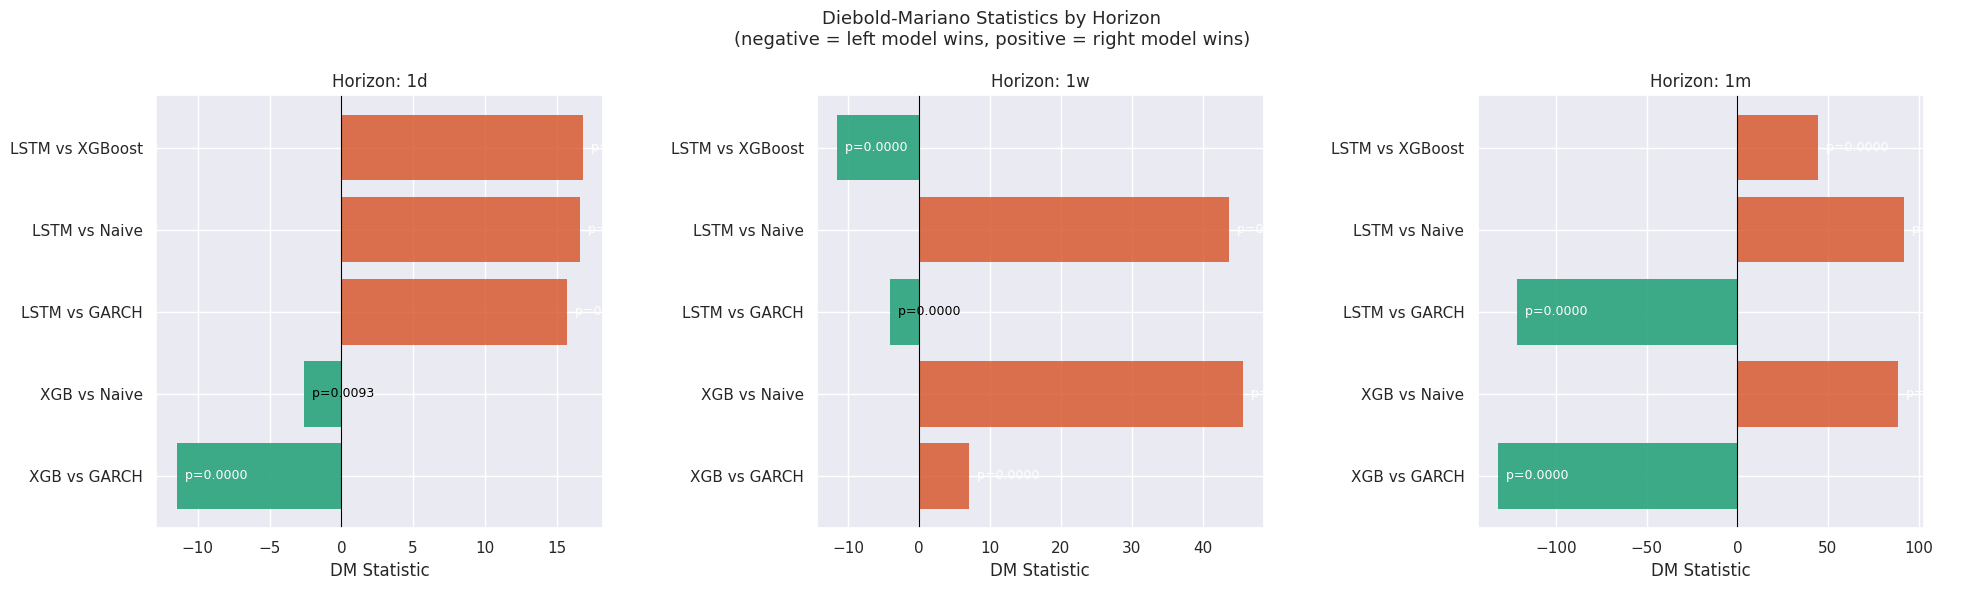

Chart 13: LSTM Training Curves


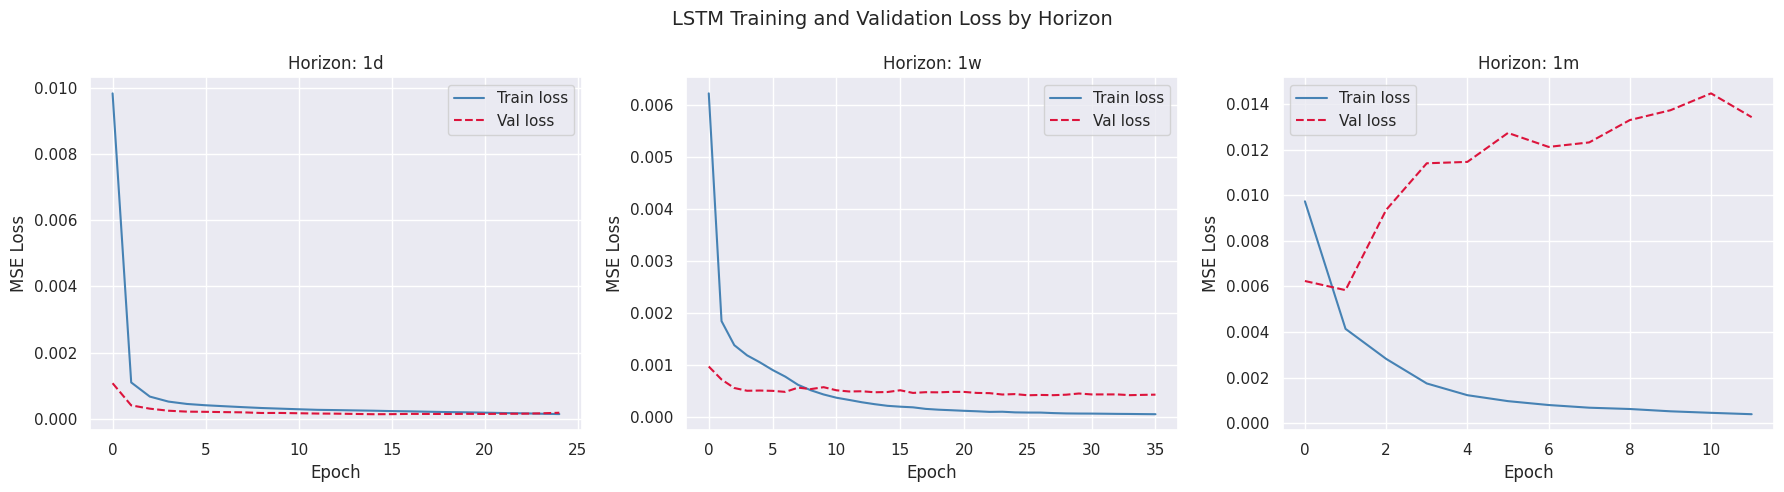


ALL SUMMARY CHARTS COMPLETE

Figures saved to: outputs/figures
Metrics saved to: outputs/metrics

Charts generated:
  1.  EDA — Price, Returns, Rolling Volatility
  2.  Return Distribution
  3.  Volume and Buy Pressure
  4.  Realized Volatility Targets
  5.  XGBoost Feature Importance
  6.  Actual vs Predicted — all models per horizon
  7.  Residual Analysis — XGBoost, GARCH, LSTM
  8.  Full Metrics Comparison (RMSE and MAE)
  9.  LSTM vs XGBoost vs GARCH direct comparison
  10. LSTM vs XGBoost Residuals side by side
  11. Mincer-Zarnowitz — all models
  12. Diebold-Mariano extended — includes LSTM comparisons
  13. LSTM Training Curves

LSTM included: True

Full metrics summary:
              mae                          rmse                    
horizon        1d        1m        1w        1d        1m        1w
model                                                              
garch    0.011525  0.144791  0.032508  0.015800  0.158423  0.040536
lstm     0.015229  0.074715  0.030994 

In [ ]:
# ============================================================
# FINAL SUMMARY — ALL CHARTS INCLUDING LSTM
# Run this cell after all other sections have been run.
# If LSTM was skipped, LSTM charts are automatically omitted.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

sns.set_theme(style='darkgrid')
HORIZONS_LIST = list(HORIZONS.keys())  # ['1d', '1w', '1m']

# Detect whether LSTM predictions exist on disk
lstm_available = all(
    os.path.exists(f'{DIR_PREDS}/lstm_{h}_predictions.csv')
    for h in HORIZONS_LIST
)
print(f'LSTM predictions available: {lstm_available}')
print('Generating all summary charts...\n')

# ── Helper: load and align all model predictions for one horizon ──────────────
def load_all_preds(h, include_lstm=False):
    naive = pd.read_csv(f'{DIR_PREDS}/naive_{h}_predictions.csv')
    garch = pd.read_csv(f'{DIR_PREDS}/garch_{h}_predictions.csv')
    xgb   = pd.read_csv(f'{DIR_PREDS}/xgb_{h}_predictions.csv')
    for df_ in [naive, garch, xgb]:
        df_['timestamp'] = pd.to_datetime(df_['timestamp'])
    dfs = {'naive': naive, 'garch': garch, 'xgboost': xgb}
    if include_lstm:
        lstm = pd.read_csv(f'{DIR_PREDS}/lstm_{h}_predictions.csv')
        lstm['timestamp'] = pd.to_datetime(lstm['timestamp'])
        dfs['lstm'] = lstm
    # Align on common timestamps
    common = set(naive['timestamp']) & set(garch['timestamp']) & set(xgb['timestamp'])
    if include_lstm and 'lstm' in dfs:
        common = common & set(dfs['lstm']['timestamp'])
    for key in dfs:
        dfs[key] = dfs[key][dfs[key]['timestamp'].isin(common)].sort_values('timestamp').reset_index(drop=True)
    return dfs


# ════════════════════════════════════════════════════════════
# CHART 1 — EDA: Price, Returns, Rolling Volatility
# ════════════════════════════════════════════════════════════
print('Chart 1: EDA — Price, Returns, Rolling Volatility')
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='normal', y=1.01)

axes[0].plot(df.index, df['close'], color='steelblue', linewidth=0.6)
axes[0].set_title('Bitcoin Close Price (USD)')
axes[0].set_ylabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].plot(df.index, df['log_return'], color='darkorange', linewidth=0.4, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('Hourly Log Returns')
axes[1].set_ylabel('Log Return')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

roll_vol = df['log_return'].rolling(window=BARS_PER_MONTH).std() * np.sqrt(BARS_PER_MONTH)
axes[2].plot(df.index, roll_vol, color='crimson', linewidth=0.6)
axes[2].set_title('Rolling 30-Day Realized Volatility')
axes[2].set_ylabel('Volatility')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/summary_01_eda_price_returns_vol.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# CHART 2 — Return Distribution
# ════════════════════════════════════════════════════════════
print('Chart 2: Return Distribution')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Return Distribution Analysis', fontsize=15, fontweight='normal')

axes[0].hist(df['log_return'].dropna(), bins=200, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Return Distribution')
axes[0].set_xlabel('Log Return')
axes[0].set_ylabel('Frequency')

abs_ret = df['log_return'].abs()
sc = axes[1].scatter(df.index, df['log_return'], c=abs_ret, cmap='RdYlGn_r', s=0.5, alpha=0.6)
axes[1].set_title('Returns Colored by Magnitude')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log Return')
plt.colorbar(sc, ax=axes[1], label='|Return|')

plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/summary_02_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# CHART 3 — Volume and Buy Pressure
# ════════════════════════════════════════════════════════════
print('Chart 3: Volume and Buy Pressure')
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Volume and Market Pressure', fontsize=15, fontweight='normal')

roll_vol_7d = df['volume'].rolling(BARS_PER_WEEK).mean()
axes[0].plot(df.index, roll_vol_7d, color='purple', linewidth=0.7)
axes[0].set_title('7-Day Rolling Average Volume (BTC)')
axes[0].set_ylabel('Volume (BTC)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

if 'buy_pressure_ratio' not in df.columns:
    df['buy_pressure_ratio'] = df['taker_buy_base_volume'] / df['volume'].replace(0, np.nan)
roll_pressure = df['buy_pressure_ratio'].rolling(BARS_PER_WEEK).mean()
axes[1].plot(df.index, roll_pressure, color='teal', linewidth=0.7)
axes[1].axhline(0.5, color='black', linewidth=0.5, linestyle='--', label='Neutral (0.5)')
axes[1].set_title('7-Day Rolling Buy Pressure Ratio')
axes[1].set_ylabel('Buy Pressure Ratio')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/summary_03_volume_pressure.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# CHART 4 — Realized Volatility Targets
# ════════════════════════════════════════════════════════════
print('Chart 4: Realized Volatility Targets')
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle('Forward-Looking Realized Volatility Targets', fontsize=15, fontweight='normal')
colors  = ['steelblue', 'darkorange', 'crimson']
targets = ['future_1d_vol', 'future_1w_vol', 'future_1m_vol']
labels  = ['1-Day Ahead RV', '1-Week Ahead RV', '1-Month Ahead RV']
for ax, col, label, color in zip(axes, targets, labels, colors):
    ax.plot(df.index, df[col], color=color, linewidth=0.5, alpha=0.8)
    ax.set_title(f'Target: {label}')
    ax.set_ylabel('Realized Volatility')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/summary_04_targets_all_horizons.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# CHART 5 — XGBoost Feature Importance
# ════════════════════════════════════════════════════════════
print('Chart 5: XGBoost Feature Importance')
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
fig.suptitle('XGBoost Feature Importance — Top 20 by Horizon', fontsize=15, fontweight='normal')
for ax, h in zip(axes, HORIZONS_LIST):
    model = xgb_models[h]
    importance = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    top20 = importance.nlargest(20)
    top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Horizon: {h}')
    ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/summary_05_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# CHART 6 — Actual vs Predicted (all models including LSTM)
# ════════════════════════════════════════════════════════════
print('Chart 6: Actual vs Predicted — all models per horizon')
model_styles = {
    'naive':   ('orange',    ':',  0.6, 0.6),
    'garch':   ('crimson',   '--', 0.7, 0.7),
    'xgboost': ('steelblue', '-',  0.7, 0.8),
    'lstm':    ('#1D9E75',   '-',  0.7, 0.85),
}
for h in HORIZONS_LIST:
    preds = load_all_preds(h, include_lstm=lstm_available)
    actual = preds['naive']['actual']
    timestamps = preds['naive']['timestamp']

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(timestamps, actual, color='black', linewidth=0.8, label='Actual', alpha=0.9, zorder=5)

    for model_name, (color, ls, lw, alpha) in model_styles.items():
        if model_name in preds:
            # align to naive timestamps for consistent length
            p = preds[model_name]
            merged = pd.merge(
                pd.DataFrame({'timestamp': timestamps}),
                p[['timestamp', 'predicted']],
                on='timestamp', how='left'
            )
            ax.plot(merged['timestamp'], merged['predicted'],
                    color=color, linewidth=lw, linestyle=ls,
                    label=model_name.capitalize(), alpha=alpha)

    ax.set_title(f'Actual vs Predicted Realized Volatility — Horizon: {h}', fontsize=13)
    ax.set_ylabel('Realized Volatility')
    ax.set_xlabel('Date')
    ax.legend(loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.tight_layout()
    plt.savefig(f'{DIR_FIGURES}/summary_06_actual_vs_predicted_{h}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════
# CHART 7 — Residual Analysis (XGBoost, GARCH, LSTM)
# ════════════════════════════════════════════════════════════
print('Chart 7: Residual Analysis')
for h in HORIZONS_LIST:
    preds = load_all_preds(h, include_lstm=lstm_available)

    models_to_plot = ['xgboost', 'garch']
    if lstm_available:
        models_to_plot.append('lstm')

    n_cols = len(models_to_plot)
    fig, axes = plt.subplots(2, n_cols, figsize=(7 * n_cols, 10))
    fig.suptitle(f'Residual Analysis — Horizon: {h}', fontsize=14)

    colors_map = {'xgboost': 'steelblue', 'garch': 'crimson', 'lstm': '#1D9E75'}

    for col_idx, model_name in enumerate(models_to_plot):
        p = preds[model_name]
        resid = p['actual'] - p['predicted']
        color = colors_map[model_name]

        # Residuals over time
        axes[0, col_idx].plot(p['timestamp'], resid, color=color, linewidth=0.5, alpha=0.7)
        axes[0, col_idx].axhline(0, color='black', linewidth=0.8, linestyle='--')
        axes[0, col_idx].set_title(f'{model_name.capitalize()} Residuals Over Time')
        axes[0, col_idx].set_ylabel('Residual')

        # Residual distribution
        axes[1, col_idx].hist(resid.dropna(), bins=100, color=color, alpha=0.8, edgecolor='none')
        axes[1, col_idx].set_title(f'{model_name.capitalize()} Residual Distribution')
        axes[1, col_idx].set_xlabel('Residual')

    plt.tight_layout()
    plt.savefig(f'{DIR_FIGURES}/summary_07_residuals_{h}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════
# CHART 8 — Full Metrics Comparison (RMSE and MAE)
# includes LSTM if available
# ════════════════════════════════════════════════════════════
print('Chart 8: Full Metrics Comparison including LSTM')

# Build full metrics table including LSTM if available
full_metrics = metrics_df.copy()

if lstm_available:
    lstm_metric_rows = []
    for h in HORIZONS_LIST:
        lstm_df = pd.read_csv(f'{DIR_PREDS}/lstm_{h}_predictions.csv')
        m = evaluate_predictions(
            lstm_df['actual'].values,
            lstm_df['predicted'].values,
            'lstm', h
        )
        lstm_metric_rows.append(m)
    lstm_metrics_df = pd.DataFrame(lstm_metric_rows)
    full_metrics = pd.concat([full_metrics, lstm_metrics_df], ignore_index=True)

# Save the updated full metrics
full_metrics.to_csv(f'{DIR_METRICS}/metrics_summary_full.csv', index=False)
print('\nFull metrics table (all models):')
pivot_full = full_metrics.pivot_table(index='model', columns='horizon', values=['rmse', 'mae'])
print(pivot_full.round(6))

# Plot
model_order = [m for m in ['naive', 'garch', 'xgboost', 'lstm'] if m in full_metrics['model'].values]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RMSE and MAE — All Models and Horizons', fontsize=15, fontweight='normal')

for ax, metric in zip(axes, ['rmse', 'mae']):
    pivot = full_metrics.pivot_table(index='model', columns='horizon', values=metric)
    pivot = pivot.loc[[m for m in model_order if m in pivot.index]]
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='none')
    ax.set_title(f'{metric.upper()} by Model and Horizon')
    ax.set_ylabel(metric.upper())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Horizon')

plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/summary_08_error_comparison_all_models.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# CHART 9 — LSTM vs XGBoost vs GARCH direct comparison
# (only runs if LSTM is available)
# ════════════════════════════════════════════════════════════
if lstm_available:
    print('Chart 9: LSTM vs XGBoost vs GARCH — Direct Comparison per Horizon')
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle('LSTM vs XGBoost vs GARCH — Actual vs Predicted per Horizon', fontsize=14, fontweight='normal')

    for ax, h in zip(axes, HORIZONS_LIST):
        preds = load_all_preds(h, include_lstm=True)
        ts = preds['xgboost']['timestamp']
        actual = preds['xgboost']['actual']

        ax.plot(ts, actual, color='black', linewidth=0.8, label='Actual', alpha=0.9)
        ax.plot(preds['xgboost']['timestamp'], preds['xgboost']['predicted'],
                color='steelblue', linewidth=0.7, label='XGBoost', alpha=0.8)
        ax.plot(preds['garch']['timestamp'], preds['garch']['predicted'],
                color='crimson', linewidth=0.7, linestyle='--', label='GARCH', alpha=0.7)
        ax.plot(preds['lstm']['timestamp'], preds['lstm']['predicted'],
                color='#1D9E75', linewidth=0.7, label='LSTM', alpha=0.85)

        ax.set_title(f'Horizon: {h}')
        ax.set_ylabel('Realized Volatility')
        ax.legend(loc='upper right', fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(f'{DIR_FIGURES}/summary_09_lstm_vs_xgb_vs_garch.png', dpi=150, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════
# CHART 10 — LSTM Residuals vs XGBoost Residuals side by side
# (only runs if LSTM is available)
# ════════════════════════════════════════════════════════════
if lstm_available:
    print('Chart 10: LSTM vs XGBoost Residuals — Side by Side per Horizon')
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('LSTM vs XGBoost Residuals by Horizon', fontsize=14, fontweight='normal')

    for row_idx, h in enumerate(HORIZONS_LIST):
        preds = load_all_preds(h, include_lstm=True)

        xgb_resid  = preds['xgboost']['actual'] - preds['xgboost']['predicted']
        lstm_resid = preds['lstm']['actual']     - preds['lstm']['predicted']

        # Align lstm to xgboost timestamps via merge
        merged = pd.merge(
            preds['xgboost'][['timestamp']].assign(xgb_resid=xgb_resid.values),
            preds['lstm'][['timestamp']].assign(lstm_resid=lstm_resid.values),
            on='timestamp', how='inner'
        )

        axes[row_idx, 0].plot(preds['xgboost']['timestamp'], xgb_resid,
                              color='steelblue', linewidth=0.5, alpha=0.7, label='XGBoost')
        axes[row_idx, 0].plot(preds['lstm']['timestamp'], lstm_resid,
                              color='#1D9E75', linewidth=0.5, alpha=0.7, label='LSTM')
        axes[row_idx, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
        axes[row_idx, 0].set_title(f'Residuals Over Time — {h}')
        axes[row_idx, 0].set_ylabel('Residual')
        axes[row_idx, 0].legend()

        axes[row_idx, 1].hist(xgb_resid.dropna(),  bins=80, color='steelblue',
                              alpha=0.6, edgecolor='none', label='XGBoost')
        axes[row_idx, 1].hist(lstm_resid.dropna(), bins=80, color='#1D9E75',
                              alpha=0.6, edgecolor='none', label='LSTM')
        axes[row_idx, 1].set_title(f'Residual Distribution — {h}')
        axes[row_idx, 1].set_xlabel('Residual')
        axes[row_idx, 1].legend()

    plt.tight_layout()
    plt.savefig(f'{DIR_FIGURES}/summary_10_lstm_vs_xgb_residuals.png', dpi=150, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════
# CHART 11 — Mincer-Zarnowitz Summary (all models including LSTM)
# ════════════════════════════════════════════════════════════
print('Chart 11: Mincer-Zarnowitz Summary')

# Add LSTM to MZ results if available
mz_full = mz_df.copy()
if lstm_available:
    for h in HORIZONS_LIST:
        lstm_df = pd.read_csv(f'{DIR_PREDS}/lstm_{h}_predictions.csv')
        alpha, beta, r2 = mincer_zarnowitz(lstm_df['actual'].values, lstm_df['predicted'].values)
        mz_full = pd.concat([mz_full, pd.DataFrame([{
            'model': 'lstm', 'horizon': h,
            'mz_alpha': alpha, 'mz_beta': beta, 'mz_r2': r2
        }])], ignore_index=True)

mz_full.to_csv(f'{DIR_METRICS}/mincer_zarnowitz_full.csv', index=False)
print('\nMincer-Zarnowitz results (perfect forecast: alpha=0, beta=1):')
print(mz_full.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Mincer-Zarnowitz Results — All Models (perfect: alpha=0, beta=1, R²=1)', fontsize=13, fontweight='normal')

model_colors = {'naive': 'orange', 'garch': 'crimson', 'xgboost': 'steelblue', 'lstm': '#1D9E75'}

for ax, metric, ideal, title in zip(
    axes,
    ['mz_alpha', 'mz_beta', 'mz_r2'],
    [0, 1, 1],
    ['Alpha (ideal = 0)', 'Beta (ideal = 1)', 'R-squared (ideal = 1)']
):
    pivot = mz_full.pivot(index='model', columns='horizon', values=metric)
    pivot = pivot.loc[[m for m in ['naive', 'garch', 'xgboost', 'lstm'] if m in pivot.index]]
    pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='none')
    ax.axhline(ideal, color='black', linewidth=1, linestyle='--', label=f'Ideal ({ideal})')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Horizon', fontsize=8)

plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/summary_11_mincer_zarnowitz_all_models.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# CHART 12 — Diebold-Mariano Extended (add LSTM comparisons)
# ════════════════════════════════════════════════════════════
print('Chart 12: Diebold-Mariano Extended including LSTM')

dm_full = dm_df.copy()
if lstm_available:
    for h in HORIZONS_LIST:
        lstm_df = pd.read_csv(f'{DIR_PREDS}/lstm_{h}_predictions.csv')
        xgb_df  = pd.read_csv(f'{DIR_PREDS}/xgb_{h}_predictions.csv')
        naive_df = pd.read_csv(f'{DIR_PREDS}/naive_{h}_predictions.csv')
        garch_df = pd.read_csv(f'{DIR_PREDS}/garch_{h}_predictions.csv')

        # Align all on common timestamps
        common = (set(lstm_df['timestamp']) & set(xgb_df['timestamp'])
                  & set(naive_df['timestamp']) & set(garch_df['timestamp']))
        for df_ in [lstm_df, xgb_df, naive_df, garch_df]:
            df_ = df_[df_['timestamp'].isin(common)].sort_values('timestamp').reset_index(drop=True)

        actual = xgb_df[xgb_df['timestamp'].isin(common)].sort_values('timestamp')['actual'].values
        lstm_p  = lstm_df[lstm_df['timestamp'].isin(common)].sort_values('timestamp')['predicted'].values
        xgb_p   = xgb_df[xgb_df['timestamp'].isin(common)].sort_values('timestamp')['predicted'].values
        naive_p = naive_df[naive_df['timestamp'].isin(common)].sort_values('timestamp')['predicted'].values
        garch_p = garch_df[garch_df['timestamp'].isin(common)].sort_values('timestamp')['predicted'].values

        dm_lg = diebold_mariano(actual, lstm_p, garch_p)
        dm_ln = diebold_mariano(actual, lstm_p, naive_p)
        dm_lx = diebold_mariano(actual, lstm_p, xgb_p)

        dm_full = pd.concat([dm_full, pd.DataFrame([
            {'horizon': h, 'comparison': 'LSTM vs GARCH', 'dm_stat': dm_lg[0], 'p_value': dm_lg[1]},
            {'horizon': h, 'comparison': 'LSTM vs Naive',  'dm_stat': dm_ln[0], 'p_value': dm_ln[1]},
            {'horizon': h, 'comparison': 'LSTM vs XGBoost','dm_stat': dm_lx[0], 'p_value': dm_lx[1]},
        ])], ignore_index=True)

dm_full.to_csv(f'{DIR_METRICS}/diebold_mariano_full.csv', index=False)
print('\nFull Diebold-Mariano results (p < 0.05 = statistically significant):')
print(dm_full.to_string(index=False))

# Plot DM stats as heatmap-style bar chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Diebold-Mariano Statistics by Horizon\n(negative = left model wins, positive = right model wins)',
             fontsize=13, fontweight='normal')

for ax, h in zip(axes, HORIZONS_LIST):
    subset = dm_full[dm_full['horizon'] == h].set_index('comparison')
    colors_dm = ['#1D9E75' if v < 0 else '#D85A30' for v in subset['dm_stat']]
    bars = ax.barh(subset.index, subset['dm_stat'], color=colors_dm, edgecolor='none', alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Horizon: {h}')
    ax.set_xlabel('DM Statistic')
    # Add p-value labels
    for i, (idx, row) in enumerate(subset.iterrows()):
        x_pos = row['dm_stat'] + (1 if row['dm_stat'] >= 0 else -1)
        ax.text(row['dm_stat'], i, f"  p={row['p_value']:.4f}", va='center', fontsize=9,
                color='white' if abs(row['dm_stat']) > 5 else 'black')

plt.tight_layout()
plt.savefig(f'{DIR_FIGURES}/summary_12_diebold_mariano_full.png', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# CHART 13 — LSTM Training Curves (if available in memory)
# ════════════════════════════════════════════════════════════
if lstm_available and 'lstm_histories' in dir():
    print('Chart 13: LSTM Training Curves')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('LSTM Training and Validation Loss by Horizon', fontsize=14, fontweight='normal')
    for ax, h in zip(axes, HORIZONS_LIST):
        hist = lstm_histories[h]
        ax.plot(hist['loss'],     color='steelblue', label='Train loss')
        ax.plot(hist['val_loss'], color='crimson',   label='Val loss', linestyle='--')
        ax.set_title(f'Horizon: {h}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend()
    plt.tight_layout()
    plt.savefig(f'{DIR_FIGURES}/summary_13_lstm_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Chart 13: LSTM training curves skipped (histories not in memory — re-run LSTM cell if needed)')


# ════════════════════════════════════════════════════════════
# FINAL SUMMARY PRINT
# ════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('ALL SUMMARY CHARTS COMPLETE')
print('='*60)
print(f'\nFigures saved to: {DIR_FIGURES}')
print(f'Metrics saved to: {DIR_METRICS}')
print(f'\nCharts generated:')
print('  1.  EDA — Price, Returns, Rolling Volatility')
print('  2.  Return Distribution')
print('  3.  Volume and Buy Pressure')
print('  4.  Realized Volatility Targets')
print('  5.  XGBoost Feature Importance')
print('  6.  Actual vs Predicted — all models per horizon')
print('  7.  Residual Analysis — XGBoost, GARCH, LSTM')
print('  8.  Full Metrics Comparison (RMSE and MAE)')
if lstm_available:
    print('  9.  LSTM vs XGBoost vs GARCH direct comparison')
    print('  10. LSTM vs XGBoost Residuals side by side')
print('  11. Mincer-Zarnowitz — all models')
print('  12. Diebold-Mariano extended — includes LSTM comparisons')
if lstm_available and 'lstm_histories' in dir():
    print('  13. LSTM Training Curves')
print(f'\nLSTM included: {lstm_available}')
print('\nFull metrics summary:')
print(full_metrics.pivot_table(index='model', columns='horizon', values=['rmse','mae']).round(6).to_string())
